**Guideline pof the file, how it is structured**

This notebook is organized around building daily entertainment-based machine learning models. The main idea is to prepare one daily panel from YouTube, Spotify, Netflix, Prime Video, and academic calendar data, then use that panel for two prediction tasks: final exam period prediction and summer work period prediction.

**1. ML - Data Preparation**

In the first part, I prepare the dataset that will be used by all machine learning models.

I start by importing the necessary libraries for data handling, visualization, and machine learning. Then I define the project paths for the entertainment datasets, academic calendar dataset, and the results folder.

After loading the raw datasets, I standardize the date structure by converting date columns into datetime format. For YouTube and Spotify, I also prepare timestamp-based variables because these platforms include activity start times. This allows me to create late-evening/night activity indicators, especially activities after 21:30.

Then I create a common date range across all entertainment platforms. This makes sure that the daily panel is built only on dates where the datasets can be compared consistently. I also process the academic calendar and assign each date into an analysis period such as ordinary term, final exam period, or summer work period.

After that, I create daily-level entertainment variables for each platform:

- YouTube daily activity counts
- YouTube watched/search counts
- YouTube after-21:30 activity counts
- Spotify daily hours, stream counts, unique tracks
- Spotify after-21:30 activity variables
- Netflix daily count
- Prime Video daily count

I also include simple plot checks for YouTube, Spotify, Netflix, and Prime Video to visually confirm that the daily aggregations look reasonable.

Finally, I merge all daily platform datasets with the academic calendar into one combined daily panel. In this panel, I add additional features such as platform active-day indicators, combined Netflix/Prime count, total entertainment event count, daily distinct platform count, and late-evening activity shares. This combined dataset becomes the base dataset for the machine learning parts.

**2. Academic - Entertainment ML**

In this part, I focus on predicting whether a day belongs to the final exam period or the ordinary academic term.

I first filter the combined daily panel to keep only ordinary term and final exam days. Then I create the binary target variable where final exam days are labeled as `1` and ordinary term days are labeled as `0`.

The selected features are daily entertainment activity variables from YouTube, Spotify, Netflix, and Prime Video. These features represent daily entertainment intensity, platform diversity, and late-evening behavior.

I split the dataset into training and test sets using the same random state and stratification. This keeps the class distribution stable and makes model results comparable.

The models used in this section are:

- Dummy Classifier as a baseline
- Logistic Regression with feature scaling
- Decision Tree with validation-based `max_depth` tuning
- K-Means clustering with PCA visualization and cluster-to-label comparison
- XGBoost with class imbalance handling
- Random Forest with balanced class weights
- Soft Voting Ensemble using supervised models

For each supervised model, I generate a classification report, confusion matrix, and performance bar plot. The main metrics are macro precision, macro recall, and macro F1-score because the classes are imbalanced.

For the decision tree, I also include a tree visualization to understand how the model splits the data. For K-Means, I treat it as an unsupervised analysis and then compare the discovered clusters with the academic labels afterward.

At the end of this section, I collect all model results into a comparison table and create plots for overall model comparison, F1-score, precision, and recall. These outputs are saved under `MachineLearning/results`.

**3. Summer Work - Entertainment ML**

In the final part, I repeat a similar machine learning structure, but this time the focus is summer work period prediction.

I prepare a new dataset by filtering the combined daily panel to ordinary term and summer work period days. The target variable labels summer work days as `1` and ordinary term days as `0`.

This section uses a similar feature set, but it also includes the late-evening share variables more explicitly. The goal is to see whether summer work days have a more distinguishable entertainment pattern compared with ordinary academic days.

The dataset is split into training and test sets with stratification. A separate results folder is used for summer work period outputs.

The models used in this section are:

- Dummy Classifier
- Logistic Regression
- Decision Tree with validation-based `max_depth` tuning
- K-Means clustering with PCA visualization
- XGBoost with class imbalance handling
- Random Forest
- Soft Voting Ensemble using supervised models

K-Means is evaluated separately as a clustering method, while the ensemble combines only supervised models. This is because K-Means is not a supervised classifier in the same way as logistic regression, decision tree, XGBoost, and random forest.

For every model, I save classification reports, confusion matrices, and performance plots. At the end, I create a summer model comparison table and visualization. The comparison highlights macro F1-score, macro precision, and macro recall separately so that the best-performing model for each metric can be seen more clearly.

**If you do not have the necessary external libraries one can run the below code to install the libraries.**

In [176]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [177]:
#----------------------IMPORTS-----------------------#

# Importing necessary libraries for data manipulation, visualization and machine learning.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path

In [178]:
#----------------------DATASET PREPARATION-----------------------#
# Adding the combined daily dataset to the machine learning dataset.

project_root = Path.cwd()
if project_root.name == "MachineLearning":
    project_root = project_root.parent



# Defining paths of the files for easy reference and avoiding path issues in the folder structure.
youtube_path = project_root / "data_github/youtube_public/youtube_activity_public.csv"
spotify_path = project_root / "data_github/spotify_public/spotify_streaming_public.csv"
netflix_path = project_root / "data_github/netflix_public/netflix_viewing_public.csv"
prime_path = project_root / "data_github/prime_video_public/prime_video_watch_history_public.csv"
calendar_path = project_root / "data_github/academical_calendar/academicCalendar.jsonl"


# This is the path to store the results. It is in the MachineLearning/results
result_path = project_root / "MachineLearning/results/ACADEMICAL_PERIOD"


In [179]:
#--------------LOADING THE DATASETS-----------------------#
youtube_data = pd.read_csv(youtube_path)
spotify_data = pd.read_csv(spotify_path)
netflix_data = pd.read_csv(netflix_path)
prime_data = pd.read_csv(prime_path)
calendar_data = pd.read_json(calendar_path, lines=True)

print("Loaded datasets:")
print("YouTube:", youtube_data.shape)
print("Spotify:", spotify_data.shape)
print("Netflix:", netflix_data.shape)
print("Prime Video:", prime_data.shape)
print("Academic calendar:", calendar_data.shape)

Loaded datasets:
YouTube: (34317, 16)
Spotify: (178202, 16)
Netflix: (2493, 11)
Prime Video: (719, 17)
Academic calendar: (15, 23)


In [180]:
#----------------------DATASET ADDING TIME STAMPS -----------------------#

# Having a common date that we would build the foundation of the ML. 

# For each of the data set making sure that we use a common date format and a common date column name. We will use "fine_date" as the common date column name.


for data in [youtube_data, spotify_data, netflix_data, prime_data]:
    data["fine_date"] = pd.to_datetime(data["fine_date"])



# YouTube and Spotify have exact timestamps, so they can be used for after-21:30 variables.
youtube_data["fine_time_start_dt"] = pd.to_datetime(
    youtube_data["fine_time_start"],
    errors="coerce",
    utc=True
).dt.tz_convert("Europe/Istanbul")

spotify_data["fine_time_start_dt"] = pd.to_datetime(
    spotify_data["fine_time_start"],
    errors="coerce",
    utc=True,
    format="mixed"
).dt.tz_convert("Europe/Istanbul")


# Spotify has different timestamps formats, I was getting 5404 rows rthat had invalid timestamps. I tried a different format to fix the issue. 
print("Invalid Spotify timestamps:", spotify_data["fine_time_start_dt"].isna().sum())


# Since we are interested in the late-evening / night activity, we will create a binary variable that indicates whether the activity started after 21:30 or not. This will be our target variable for the machine learning model.


# Building necessary columns for the future macxhine learning developments. Focusing on late evening night activities.
# After 21:30 until 04:59 is treated as late-evening / night activity.
youtube_data["is_after_2130"] = (
    (youtube_data["fine_time_start_dt"].dt.hour > 21) |
    (
        (youtube_data["fine_time_start_dt"].dt.hour == 21) &
        (youtube_data["fine_time_start_dt"].dt.minute >= 30)
    ) |
    (youtube_data["fine_time_start_dt"].dt.hour < 5)
)

# Same for Spotify.
spotify_data["is_after_2130"] = (
    (spotify_data["fine_time_start_dt"].dt.hour > 21) |
    (
        (spotify_data["fine_time_start_dt"].dt.hour == 21) &
        (spotify_data["fine_time_start_dt"].dt.minute >= 30)
    ) |
    (spotify_data["fine_time_start_dt"].dt.hour < 5)
)

#Checkcing before the ML so no errors in the timestamps.

print("Invalid YouTube timestamps:", youtube_data["fine_time_start_dt"].isna().sum())
print("Invalid Spotify timestamps:", spotify_data["fine_time_start_dt"].isna().sum())


Invalid Spotify timestamps: 0
Invalid YouTube timestamps: 0
Invalid Spotify timestamps: 0


In [181]:
#----------------------DATASET COMMON DATE RANGE-----------------------#

# Adding a common date range for all datasets to make sure that we are comparing the same time periods. We will create a new dataframe that contains all the dates in the common date range and then merge it with each of the datasets.
common_start_date = max(
    youtube_data["fine_date"].min(),
    spotify_data["fine_date"].min(),
    netflix_data["fine_date"].min(),
    prime_data["fine_date"].min()
)


# Adding a common end date as well, to make sure that we are comparing the same time periods. We will create a new dataframe that contains all the dates in the common date range and then merge it with each of the datasets.
common_end_date = min(
    youtube_data["fine_date"].max(),
    spotify_data["fine_date"].max(),
    netflix_data["fine_date"].max(),
    prime_data["fine_date"].max()
)

all_dates = pd.DataFrame({
    "fine_date": pd.date_range(common_start_date, common_end_date, freq="D")})



calendar_rows = []

#----------------------DATASET DATE CLASSES-----------------------#
# Assigning the classes based on the academic calendar.
# We will create a new dataframe that contains all the dates in the common date range and then merge it with each of the datasets. 
# We will also create a new column that indicates whether the date is in the ordinary term, final exam period or summer work period.
for _, row in calendar_data.iterrows():
    term_start = pd.to_datetime(row["term_start_date"])
    final_start = pd.to_datetime(row["final_exam_start_date"])
    final_end = pd.to_datetime(row["final_exam_end_date"])

    for date_value in pd.date_range(term_start, final_end, freq="D"):
        if final_start <= date_value <= final_end:
            academic_period = "final_exam"
        else:
            academic_period = "ordinary_term"

        if row["term"] == "summer":
            analysis_period = "summer_work_period"
        else:
            analysis_period = academic_period

        calendar_rows.append({
            "fine_date": date_value,
            "academic_year": row["academic_year"],
            "term": row["term"],
            "academic_period": academic_period,
            "analysis_period": analysis_period,
            "is_final_exam_period": academic_period == "final_exam",
            "is_ordinary_term_day": academic_period == "ordinary_term"})

calendar_daily = pd.DataFrame(calendar_rows).drop_duplicates("fine_date", keep="first")

print("Common date range:")
print(common_start_date, "to", common_end_date)
print("Number of dates:", len(all_dates))


Common date range:
2022-04-17 00:00:00 to 2026-03-10 00:00:00
Number of dates: 1424


In [182]:
#----------------------YOUTUBE DAILY VARIABLES-----------------------#

# This part focuses on creating variables for youtube that will be used in the ml models.

# Creating daily aggregates for YouTube data. We will create the following daily variables:
# - youtube_daily_total_count: Total number of YouTube activities per day.
# - youtube_daily_watched_count: Total number of YouTube "Watched" activities per day.
# - youtube_daily_search_count: Total number of YouTube "Searched for" activities per day.
# - youtube_after_2130_count: Total number of YouTube activities that started after 21:30 per day.
# - youtube_after_2130_watched_count: Total number of YouTube "Watched" activities that started after 21:30 per day.


youtube_daily_total = (
    youtube_data
    .groupby("fine_date")
    .size()
    .reset_index(name="youtube_daily_total_count"))

youtube_daily_watched = (
    youtube_data[youtube_data["action"] == "Watched"]
    .groupby("fine_date")
    .size()
    .reset_index(name="youtube_daily_watched_count"))

youtube_daily_search = (
    youtube_data[youtube_data["action"] == "Searched for"]
    .groupby("fine_date")
    .size()
    .reset_index(name="youtube_daily_search_count")
)

youtube_after_2130 = (
    youtube_data[youtube_data["is_after_2130"]]
    .groupby("fine_date")
    .size()
    .reset_index(name="youtube_after_2130_count")
)

youtube_after_2130_watched = (
    youtube_data[
        youtube_data["is_after_2130"] &
        (youtube_data["action"] == "Watched")
    ]
    .groupby("fine_date")
    .size()
    .reset_index(name="youtube_after_2130_watched_count")
)

youtube_daily = (
    all_dates
    .merge(youtube_daily_total, on="fine_date", how="left")
    .merge(youtube_daily_watched, on="fine_date", how="left")
    .merge(youtube_daily_search, on="fine_date", how="left")
    .merge(youtube_after_2130, on="fine_date", how="left")
    .merge(youtube_after_2130_watched, on="fine_date", how="left")
)

for column in youtube_daily.columns:
    if column != "fine_date":
        youtube_daily[column] = youtube_daily[column].fillna(0).astype(int)

print("YouTube daily sample:")
print(youtube_daily.sample(5))
print(youtube_daily.head())


YouTube daily sample:
      fine_date  youtube_daily_total_count  youtube_daily_watched_count  \
519  2023-09-18                          0                            0   
592  2023-11-30                          0                            0   
1142 2025-06-02                         32                           31   
949  2024-11-21                          3                            1   
1114 2025-05-05                          1                            0   

      youtube_daily_search_count  youtube_after_2130_count  \
519                            0                         0   
592                            0                         0   
1142                           1                         0   
949                            2                         0   
1114                           1                         1   

      youtube_after_2130_watched_count  
519                                  0  
592                                  0  
1142                           

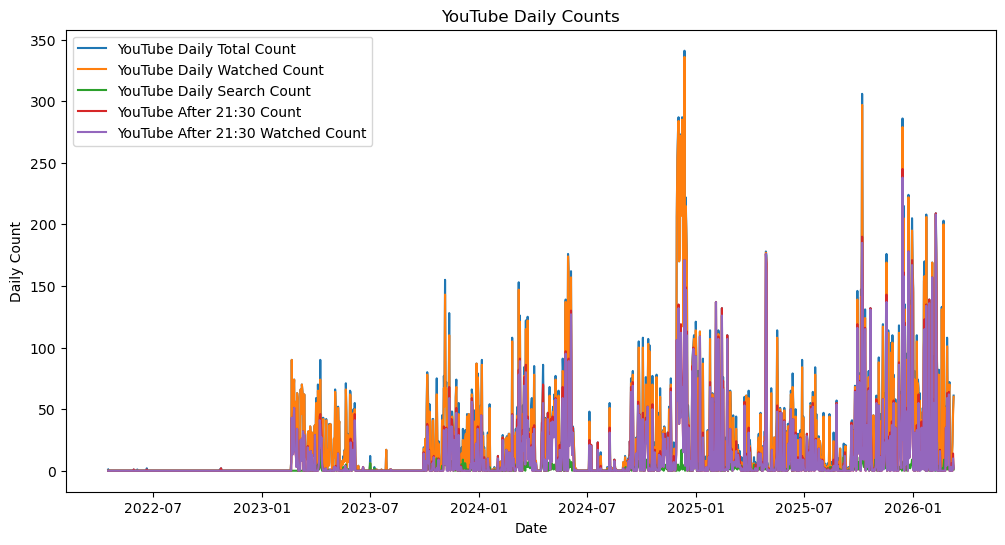

In [183]:
#------------- PLOT CHECK ------------
# Plotting the youtube daily counts to make sure the dataset uploaded correctly.
plt.figure(figsize=(12, 6))
plt.plot(youtube_daily["fine_date"], youtube_daily["youtube_daily_total_count"], label="YouTube Daily Total Count")
plt.plot(youtube_daily["fine_date"], youtube_daily["youtube_daily_watched_count"], label="YouTube Daily Watched Count")
plt.plot(youtube_daily["fine_date"], youtube_daily["youtube_daily_search_count"], label="YouTube Daily Search Count")
plt.plot(youtube_daily["fine_date"], youtube_daily["youtube_after_2130_count"], label="YouTube After 21:30 Count")
plt.plot(youtube_daily["fine_date"], youtube_daily["youtube_after_2130_watched_count"], label="YouTube After 21:30 Watched Count")
plt.xlabel("Date")
plt.ylabel("Daily Count")
plt.title("YouTube Daily Counts")
plt.legend()
plt.show()

In [184]:
#----------------------NETFLIX AND PRIME VIDEO DAILY VARIABLES-----------------------#

# This part focuses on creating variables for netflix and prime video that will be used in the ml models.

# Creating daily aggregates for Netflix and Prime Video data. We will create the following daily variables:
# - netflix_daily_count: Total number of Netflix activities per day.
# - prime_video_daily_count: Total number of Prime Video activities per day.


netflix_daily = (
    netflix_data
    .groupby("fine_date")
    .size()
    .reset_index(name="netflix_daily_count")
)

prime_daily = (
    prime_data
    .groupby("fine_date")
    .size()
    .reset_index(name="prime_video_daily_count")
)

netflix_daily = all_dates.merge(netflix_daily, on="fine_date", how="left")
prime_daily = all_dates.merge(prime_daily, on="fine_date", how="left")

netflix_daily["netflix_daily_count"] = netflix_daily["netflix_daily_count"].fillna(0).astype(int)
prime_daily["prime_video_daily_count"] = prime_daily["prime_video_daily_count"].fillna(0).astype(int)

print("Netflix daily sample:")
print(netflix_daily.head())
print(netflix_daily.sample(5))
print()
print("Prime Video daily sample:")
print(prime_daily.head())
print(prime_daily.sample(5))



Netflix daily sample:
   fine_date  netflix_daily_count
0 2022-04-17                    0
1 2022-04-18                    0
2 2022-04-19                    0
3 2022-04-20                    1
4 2022-04-21                    0
      fine_date  netflix_daily_count
1269 2025-10-07                    0
1392 2026-02-07                    1
850  2024-08-14                    0
891  2024-09-24                    0
678  2024-02-24                    0

Prime Video daily sample:
   fine_date  prime_video_daily_count
0 2022-04-17                        0
1 2022-04-18                        0
2 2022-04-19                        0
3 2022-04-20                        0
4 2022-04-21                        0
      fine_date  prime_video_daily_count
433  2023-06-24                        0
893  2024-09-26                        0
484  2023-08-14                        0
93   2022-07-19                        0
1333 2025-12-10                        0


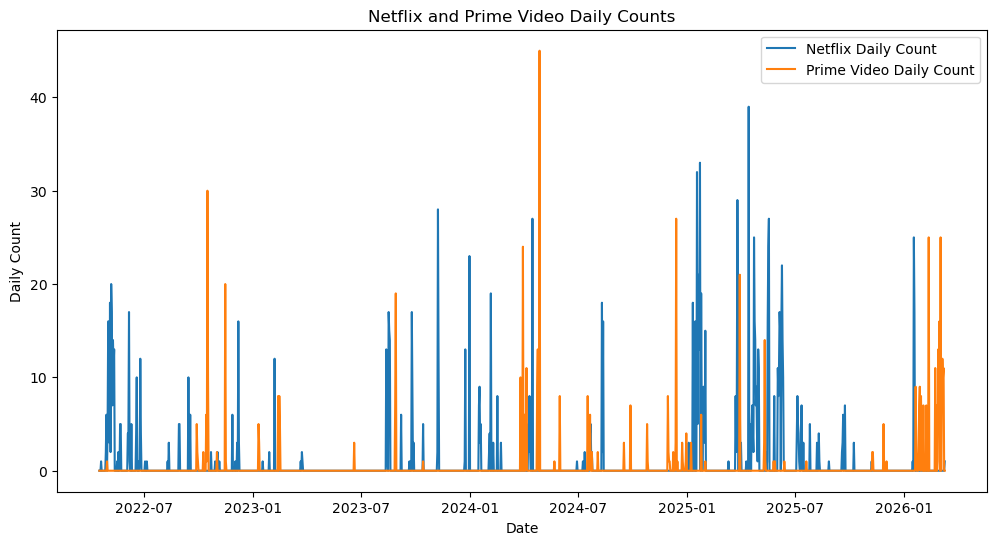

In [185]:
#------------PLOT CHECK--------------
# plotting the netflix and prime video daily counts to see if the data has been uploaded correctly.
plt.figure(figsize=(12, 6))
plt.plot(netflix_daily["fine_date"], netflix_daily["netflix_daily_count"], label="Netflix Daily Count")
plt.plot(prime_daily["fine_date"], prime_daily["prime_video_daily_count"], label="Prime Video Daily Count")
plt.xlabel("Date")
plt.ylabel("Daily Count")
plt.title("Netflix and Prime Video Daily Counts")
plt.legend()
plt.show()

In [186]:
#----------------------SPOTIFY DAILY VARIABLES-----------------------#

# This part focuess on creating variables for spotify that will be used in the ml models.

# Creating daily aggregates for Spotify data. We will create the following daily variables:
# - spotify_daily_hours: Total hours played on Spotify per day.
# - spotify_daily_stream_count: Total number of Spotify streams per day.
# - spotify_daily_unique_tracks: Total number of unique tracks played on Spotify per day.
# - spotify_after_2130_hours: Total hours played on Spotify that started after 21:30 per day.
# - spotify_after_2130_stream_count: Total number of Spotify streams that started after 21:30 per day.

spotify_daily = (
    spotify_data
    .groupby("fine_date")
    .agg(
        spotify_daily_hours=("hours_played", "sum"),
        spotify_daily_stream_count=("fine_record_id", "count"),
        spotify_daily_unique_tracks=("track_ref_id", "nunique")
    )
    .reset_index()
)

spotify_after_2130 = (
    spotify_data[spotify_data["is_after_2130"]]
    .groupby("fine_date")
    .agg(
        spotify_after_2130_hours=("hours_played", "sum"),
        spotify_after_2130_stream_count=("fine_record_id", "count")
    )
    .reset_index()
)

spotify_daily = (
    all_dates
    .merge(spotify_daily, on="fine_date", how="left")
    .merge(spotify_after_2130, on="fine_date", how="left")
)

spotify_daily["spotify_daily_hours"] = spotify_daily["spotify_daily_hours"].fillna(0)
spotify_daily["spotify_daily_stream_count"] = spotify_daily["spotify_daily_stream_count"].fillna(0).astype(int)
spotify_daily["spotify_daily_unique_tracks"] = spotify_daily["spotify_daily_unique_tracks"].fillna(0).astype(int)
spotify_daily["spotify_after_2130_hours"] = spotify_daily["spotify_after_2130_hours"].fillna(0)
spotify_daily["spotify_after_2130_stream_count"] = spotify_daily["spotify_after_2130_stream_count"].fillna(0).astype(int)

print("Spotify daily sample:")
print(spotify_daily.head())
print(spotify_daily.sample(5))



Spotify daily sample:
   fine_date  spotify_daily_hours  spotify_daily_stream_count  \
0 2022-04-17             1.603053                          70   
1 2022-04-18             0.385654                          11   
2 2022-04-19             0.002694                           7   
3 2022-04-20             0.905688                         135   
4 2022-04-21             0.634982                          64   

   spotify_daily_unique_tracks  spotify_after_2130_hours  \
0                           63                  0.117174   
1                            9                  0.264308   
2                            2                  0.000000   
3                          103                  0.905688   
4                           49                  0.268858   

   spotify_after_2130_stream_count  
0                               25  
1                               10  
2                                1  
3                              135  
4                               28  
    

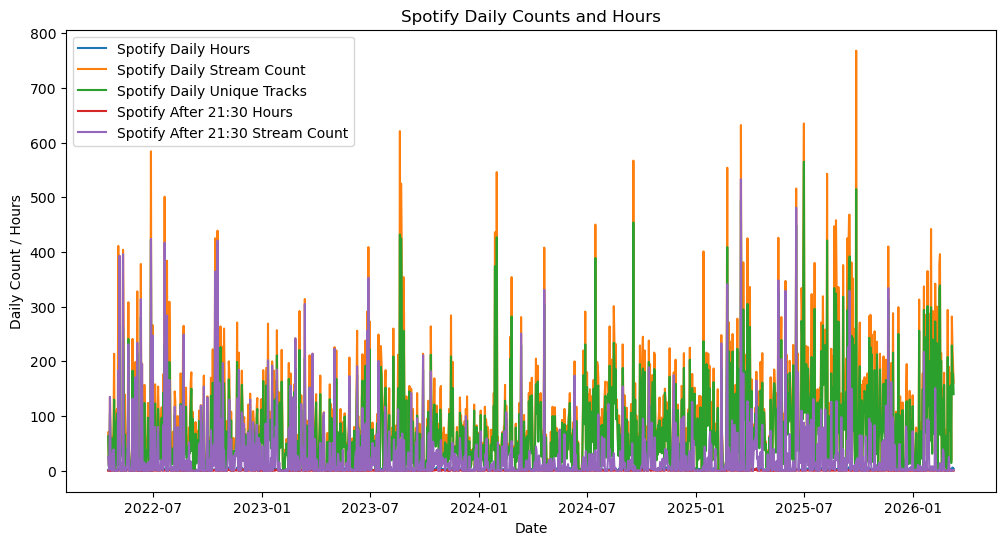

In [187]:
#------------- PLOT CHECK ------------
# Plotting the spotify daily counts to make sure the dataset uploaded correctly.
plt.figure(figsize=(12, 6))
plt.plot(spotify_daily["fine_date"], spotify_daily["spotify_daily_hours"], label="Spotify Daily Hours")
plt.plot(spotify_daily["fine_date"], spotify_daily["spotify_daily_stream_count"], label="Spotify Daily Stream Count")
plt.plot(spotify_daily["fine_date"], spotify_daily["spotify_daily_unique_tracks"], label="Spotify Daily Unique Tracks")
plt.plot(spotify_daily["fine_date"], spotify_daily["spotify_after_2130_hours"], label="Spotify After 21:30 Hours")
plt.plot(spotify_daily["fine_date"], spotify_daily["spotify_after_2130_stream_count"], label="Spotify After 21:30 Stream Count")
plt.xlabel("Date")
plt.ylabel("Daily Count / Hours")
plt.title("Spotify Daily Counts and Hours")
plt.legend()
plt.show()

In [188]:
#----------------------COMBINED DAILY PANEL-----------------------#


# Having a combined daily panel that contains all the daily variables from YouTube, Spotify, Netflix, Prime Video and the academic calendar. We will merge all the daily datasets on the "fine_date" column and then fill the missing values with 0 for the entertainment variables and with "outside_calendar" for the academic calendar variables. We will also create some additional variables that indicate whether the day is an active day for each platform and the total entertainment event count for each day.
combined_daily = (
    all_dates
    .merge(youtube_daily, on="fine_date", how="left")
    .merge(spotify_daily, on="fine_date", how="left")
    .merge(netflix_daily, on="fine_date", how="left")
    .merge(prime_daily, on="fine_date", how="left")
    .merge(calendar_daily, on="fine_date", how="left")
)


# Filling the missing values with 0 for the entertainment variables and with "outside_calendar" for the academic calendar variables.
# To make sure having a dataset that is corretly labeled troughout.
combined_daily["academic_year"] = combined_daily["academic_year"].fillna("outside_calendar")
combined_daily["term"] = combined_daily["term"].fillna("outside_calendar")
combined_daily["academic_period"] = combined_daily["academic_period"].fillna("outside_calendar")
combined_daily["analysis_period"] = combined_daily["analysis_period"].fillna("outside_calendar")

# Adding another column where we have a boolean value for whether the day is in the final exam period or not. This will be our target variable for the machine learning model.
for column in ["is_final_exam_period", "is_ordinary_term_day"]:
    combined_daily[column] = (
        combined_daily[column]
        .where(combined_daily[column].notna(), False)
        .astype(bool)
    )


#  Combining netlifx and prime daily counts to have a better
# datast that would be easier to work with in the ML models.
combined_daily["netflix_prime_daily_count"] = (
    combined_daily["netflix_daily_count"] +
    combined_daily["prime_video_daily_count"]
)


# Adding the daily days where the user was active on that platform by constrainting it with
# having an activity more than 0 for tthat day and platform.
combined_daily["youtube_active_day"] = combined_daily["youtube_daily_total_count"] > 0
combined_daily["spotify_active_day"] = combined_daily["spotify_daily_stream_count"] > 0
combined_daily["netflix_active_day"] = combined_daily["netflix_daily_count"] > 0
combined_daily["prime_video_active_day"] = combined_daily["prime_video_daily_count"] > 0
combined_daily["netflix_prime_active_day"] = combined_daily["netflix_prime_daily_count"] > 0


# Summing up the daily active platforms to have another variable that indicated
# jow many platforms the user used on specific day.
# This will give us an idea about the diversity of the user's entertainment activity on each day, which could be an important signal for the machine learning model.
combined_daily["daily_distinct_entertainment_platform_count"] = (
    combined_daily[[
        "youtube_active_day",
        "spotify_active_day",
        "netflix_active_day",
        "prime_video_active_day"
    ]]
    .sum(axis=1)
    .astype(int)
)


# Adding a variable that sums up the total entertainment event count for each day by summing up the daily counts of YouTube, Spotify, Netflix and Prime Video. This will give us an overall measure of the user's entertainment activity for each day.
combined_daily["total_entertainment_event_count"] = (
    combined_daily["youtube_daily_total_count"] +
    combined_daily["spotify_daily_stream_count"] +
    combined_daily["netflix_prime_daily_count"]
)

# Adding the share of the late-evening / night activity for YouTube and Spotify by dividing the after-21:30 counts by the total daily counts for each platform.
# This will give us a measure of how much of the user's entertainment activity is happening in the late-evening / night period, 
# which could be an important signal for the machine learning model.
combined_daily["youtube_after_2130_share"] = (
    combined_daily["youtube_after_2130_count"] /
    combined_daily["youtube_daily_total_count"].replace(0, np.nan)
).fillna(0)

combined_daily["spotify_after_2130_hour_share"] = (
    combined_daily["spotify_after_2130_hours"] /
    combined_daily["spotify_daily_hours"].replace(0, np.nan)
).fillna(0)

print("Combined daily shape:")
print(combined_daily.shape)
print()
print("Combined daily sample:")
print(combined_daily.head())
print(combined_daily.sample(5))

Combined daily shape:
(1424, 29)

Combined daily sample:
   fine_date  youtube_daily_total_count  youtube_daily_watched_count  \
0 2022-04-17                          1                            0   
1 2022-04-18                          0                            0   
2 2022-04-19                          0                            0   
3 2022-04-20                          0                            0   
4 2022-04-21                          0                            0   

   youtube_daily_search_count  youtube_after_2130_count  \
0                           0                         0   
1                           0                         0   
2                           0                         0   
3                           0                         0   
4                           0                         0   

   youtube_after_2130_watched_count  spotify_daily_hours  \
0                                 0             1.603053   
1                                 0

In [189]:
# Showing combined daily table
combined_daily.sample(20)


,fine_date,youtube_daily_total_count,youtube_daily_watched_count,youtube_daily_search_count,youtube_after_2130_count,youtube_after_2130_watched_count,spotify_daily_hours,spotify_daily_stream_count,spotify_daily_unique_tracks,spotify_after_2130_hours,...,netflix_prime_daily_count,youtube_active_day,spotify_active_day,netflix_active_day,prime_video_active_day,netflix_prime_active_day,daily_distinct_entertainment_platform_count,total_entertainment_event_count,youtube_after_2130_share,spotify_after_2130_hour_share
573,2023-11-11,44,43,1,2,2,3.652499,77,63,0.911186,...,0,True,True,False,False,False,2,121,0.045455,0.249469
26,2022-05-13,0,0,0,0,0,1.166736,286,196,0.000000,...,0,False,True,False,False,False,1,286,0.000000,0.000000
338,2023-03-21,27,27,0,15,15,1.641740,66,63,0.088397,...,0,True,True,False,False,False,2,93,0.555556,0.053843
518,2023-09-17,0,0,0,0,0,1.358593,78,70,0.948139,...,0,False,True,False,False,False,1,78,0.000000,0.697883
997,2025-01-08,9,4,5,0,0,2.299460,136,116,0.022760,...,0,True,True,False,False,False,2,145,0.000000,0.009898
1128,2025-05-19,16,7,9,2,1,6.007968,426,328,2.153251,...,0,True,True,False,False,False,2,442,0.125000,0.358399
760,2024-05-16,23,19,4,21,17,0.981428,75,59,0.981428,...,0,True,True,False,False,False,2,98,0.913043,1.000000
801,2024-06-26,0,0,0,0,0,1.325080,132,109,0.000000,...,0,False,True,False,False,False,1,132,0.000000,0.000000
814,2024-07-09,0,0,0,0,0,1.908211,65,52,0.062261,...,1,False,True,True,False,True,2,66,0.000000,0.032628
1358,2026-01-04,31,31,0,0,0,0.045076,1,1,0.000000,...,0,True,True,False,False,False,2,32,0.000000,0.000000


In [190]:
#----------------------------------------------------- RAW DATA MANIPULATIONS AND ADDING FINISHED -----------------------------------------------#

In [191]:
#------------------------ ML PREPARATIONS --------------------------------


# Copying trhe data set to make sure no accidental changes to the original combined daily dataset that we will use for the machine learning model. 
# We will filter the dataset to include only the days that are in the ordinary term and final exam periods, as these are the periods we are 
# interested in for our machine learning model. We will also drop the days that are outside of the academic calendar, as they do not have a clear label for our target variable.

ml_data = combined_daily[combined_daily["analysis_period"].isin(["ordinary_term", "final_exam"])].copy()



# Adding a binary variable that indicates whether the day is in the final exam period or not. 
# This will be our target variable for the machine learning model.
ml_data["is_final_exam"] = (ml_data["analysis_period"] == "final_exam").astype(int)



# The columns that wwe will use as features for the machine learning model. We will use the daily counts and hours for YouTube, Spotify, Netflix and Prime Video,
# as well as the daily distinct entertainment platform count. We will also use the share of the late-evening / night activity for YouTube and Spotify as features,
#  as they could be important signals for the machine learning model.
feature_columns = [
    "youtube_daily_watched_count",
    "youtube_daily_search_count",
    "youtube_after_2130_count",
    "spotify_daily_hours",
    "spotify_daily_stream_count",
    "spotify_daily_unique_tracks",
    "spotify_after_2130_hours",
    "netflix_daily_count",
    "prime_video_daily_count",
    "netflix_prime_daily_count",
    "daily_distinct_entertainment_platform_count",
]


# Checking if every column of feature exists in the ml columns
for column in feature_columns:
    if column not in ml_data.columns:
        print(f"Warning: {column} is not in the ml_data columns.")
    else :
        print(f"{column} is in the ml_data columns.")

X = ml_data[feature_columns].copy()
y = ml_data["is_final_exam"].copy()


print("ML data shape:", ml_data.shape)
print()
print("Target distribution:")
print(ml_data["analysis_period"].value_counts())
print()
print("Feature summary:")
print(X.describe().T)



youtube_daily_watched_count is in the ml_data columns.
youtube_daily_search_count is in the ml_data columns.
youtube_after_2130_count is in the ml_data columns.
spotify_daily_hours is in the ml_data columns.
spotify_daily_stream_count is in the ml_data columns.
spotify_daily_unique_tracks is in the ml_data columns.
spotify_after_2130_hours is in the ml_data columns.
netflix_daily_count is in the ml_data columns.
prime_video_daily_count is in the ml_data columns.
netflix_prime_daily_count is in the ml_data columns.
daily_distinct_entertainment_platform_count is in the ml_data columns.
ML data shape: (872, 30)

Target distribution:
analysis_period
ordinary_term    775
final_exam        97
Name: count, dtype: int64

Feature summary:
                                             count       mean        std  min  \
youtube_daily_watched_count                  872.0  30.050459  46.773801  0.0   
youtube_daily_search_count                   872.0   1.939220   2.723748  0.0   
youtube_after_213

In [192]:
#-------------------------ML IPMORTS -----------------------#
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [193]:
#------------------- TRAIN-TEST SPLIT -----------------------#


# We must make sure that if we use more than one models our model should have the same random state so that they would be comparable.
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

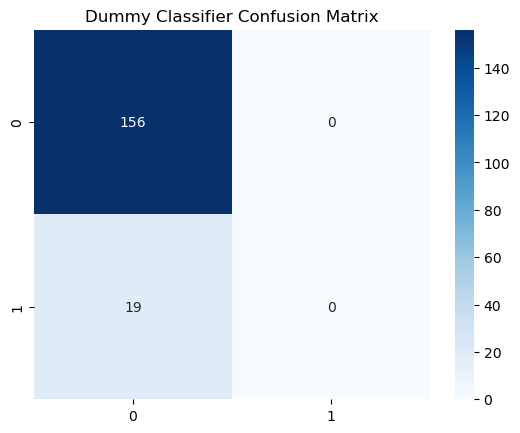

In [194]:
# Dummy classifier to have a baseline for our machine learning model. This will help us understand how well our model is performing compared to a simple baseline that always predicts the majority class.
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_clf.fit(X_train, y_train)
y_dummy_pred = dummy_clf.predict(X_test)


plt.title("Dummy Classifier Confusion Matrix")
sns.heatmap(confusion_matrix(y_test, y_dummy_pred), annot=True, fmt="d", cmap="Blues")


#Saving the confusion matrix plot for the dummy classifier.
plt.savefig(result_path / "dummy_classifier_confusion_matrix.png")
plt.show()
# Since this is dummy classifier we are expecting to have 0 precision, recall and f1-score for the final exam class, and 1 for the ordinary term class, 
# as the dummy classifier will always predict the majority class, which is the ordinary term in our case. 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


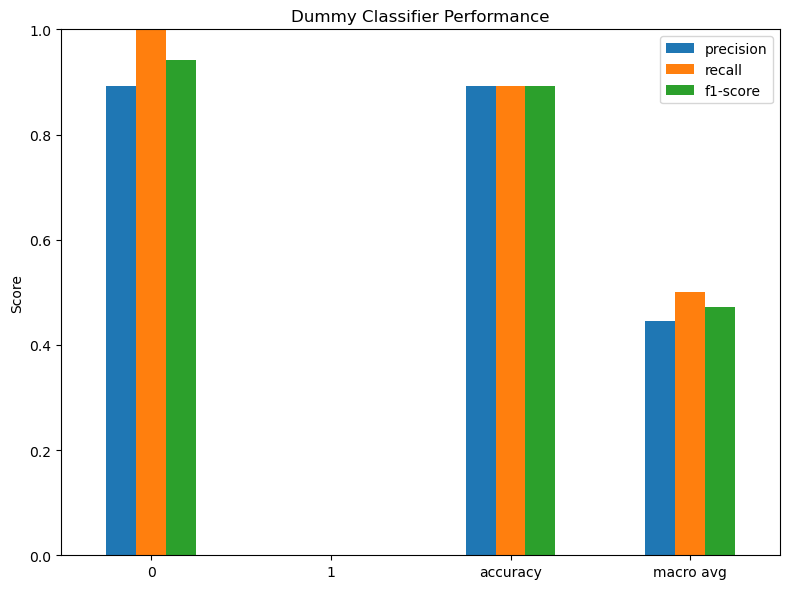

In [195]:
# Showing the scores of f1-score, precision and recall for the dummy in bar plot.
dummy_report = classification_report(y_test, y_dummy_pred, output_dict=True)
dummy_df = pd.DataFrame(dummy_report).transpose().iloc[:-1, :3]

ax = dummy_df.plot(kind="bar", figsize=(8, 6))

plt.title("Dummy Classifier Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.tight_layout()

# Saving the dummy classifier results in csv and png to the folder results.
dummy_df.to_csv(result_path / "dummy_classifier_report.csv")
plt.savefig(result_path / "dummy_classifier_performance.png", dpi=300, bbox_inches="tight")

plt.show()

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.47      0.62       156
           1       0.13      0.63      0.21        19

    accuracy                           0.49       175
   macro avg       0.52      0.55      0.41       175
weighted avg       0.83      0.49      0.57       175



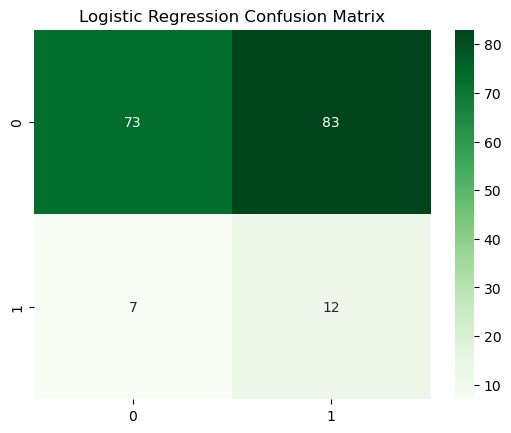

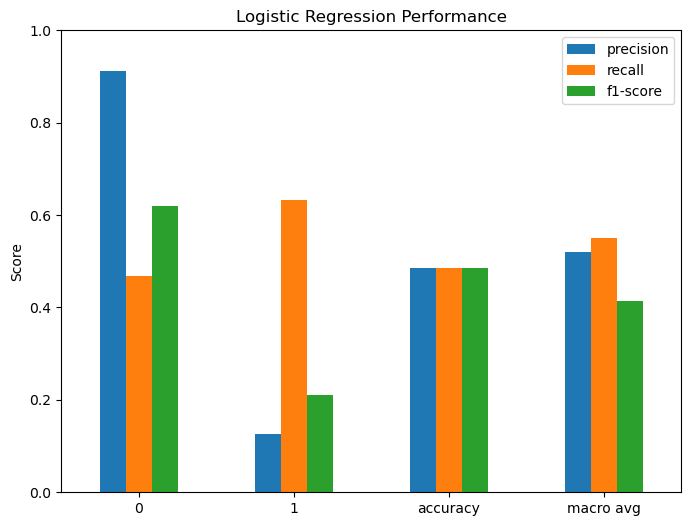

In [196]:
#---------------------LOGISTIC REGRESSION-----------------------#
# Logistic regression model to predict whether a day is in the final exam period or not based on the daily entertainment activity features.
#  I will use a pipeline to standardize the features and then fit the logistic regression model.


# Creating a pipeline that includes a standard scaler to standardize the features and a logistic regression model to predict the target variable.

# Max_iteration is to make sure model converges, as we have a small dataset and some features that could be correlated, 
# which could lead to convergence issues for the logistic regression model. By increasing the max_iter parameter,
#  we allow the model to have more iterations to find the optimal coefficients for the features, which can help improve the performance of the model.


log_reg_pipeline = Pipeline([("scaler", StandardScaler()),("model", LogisticRegression(class_weight="balanced", max_iter=1000)),])

# Implementing the pipeline to fit the logistic regression model on the training data.
log_reg_pipeline.fit(X_train, y_train)

# predicting the target variable on the test data using the fitted logistic regression model.
y_log_reg_pred = log_reg_pipeline.predict(X_test)
# Evaluating the performance of the logistic regression model by showing the classification report and confusion matrix.
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_log_reg_pred))


# Heat map for confusion matrix of logistic regression model.
plt.title("Logistic Regression Confusion Matrix")
sns.heatmap(confusion_matrix(y_test, y_log_reg_pred), annot=True, fmt="d", cmap="Greens")

# Saving the confusion matrix plot for the logistic regression model.
plt.savefig(result_path / "logistic_regression_confusion_matrix.png")

plt.show()



# bar plot for showing the macrof1 score, precision and recall scores for the logistic regression model.
log_reg_report = classification_report(y_test, y_log_reg_pred, output_dict=True)
log_reg_df = pd.DataFrame(log_reg_report).transpose().iloc[:-1, :3] 
log_reg_df.plot(kind="bar", figsize=(8, 6))
plt.title("Logistic Regression Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="upper right")

# Saving the logistic regression results in csv and png to the folder results.
log_reg_df.to_csv(result_path / "logistic_regression_report.csv")
plt.savefig(result_path / "logistic_regression_performance.png", dpi=300, bbox_inches="tight")

plt.show()


In [197]:
#---------------------------------------------- DECISION TREE CLASSIFIER----------------------------------------------#
# Decision tree classifier to predict whether a day is in the final exam period or not based on the daily entertainment activity features. 




# We can divide the train to have validation set as well to have hyperparameter tuning for the decision tree model
# We have the same random state for the train test split to make sure that the results are comparable with the logistic regression model.
# With validation set we can tune the max_depth hyperparameter of the decision tree model to find the optimal depth 
# that gives us the best performance on the validation set. This will help us avoid overfitting and 
# improve the generalization performance of the model on the test set.

x_train_sub, x_val, y_train_sub, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

max_depth_values = [2, 3, 4, 5, 6 , 7, 8, 9, 10]
best_f1_score = 0
best_max_depth = None

for max_depth in max_depth_values:
    model = DecisionTreeClassifier(class_weight="balanced", random_state=42, max_depth=max_depth)
    model.fit(x_train_sub, y_train_sub)
    y_val_pred = model.predict(x_val)
    report = classification_report(y_val, y_val_pred, output_dict=True)
    f1_score = report["macro avg"]["f1-score"]
    
    print(f"Max Depth: {max_depth}, F1 Score: {f1_score:.4f}")
    
    if f1_score > best_f1_score:
        best_f1_score = f1_score
        best_max_depth = max_depth


print(f"Best Max Depth: {best_max_depth}, Best F1 Score: {best_f1_score:.4f}")


Max Depth: 2, F1 Score: 0.3800
Max Depth: 3, F1 Score: 0.3549
Max Depth: 4, F1 Score: 0.3960
Max Depth: 5, F1 Score: 0.4276
Max Depth: 6, F1 Score: 0.4091
Max Depth: 7, F1 Score: 0.4299
Max Depth: 8, F1 Score: 0.4242
Max Depth: 9, F1 Score: 0.4204
Max Depth: 10, F1 Score: 0.4260
Best Max Depth: 7, Best F1 Score: 0.4299


Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.64      0.76       156
           1       0.16      0.58      0.26        19

    accuracy                           0.63       175
   macro avg       0.55      0.61      0.51       175
weighted avg       0.84      0.63      0.70       175



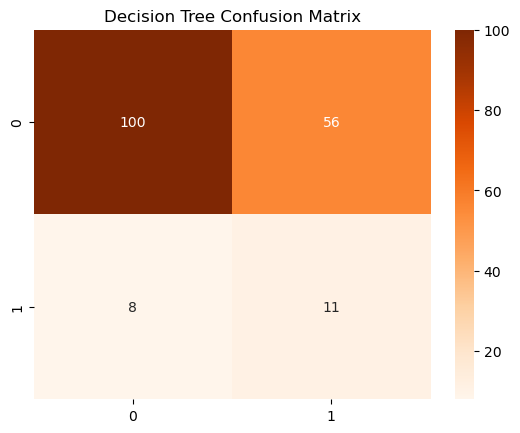

In [198]:
# Fitting the decision tree model with the best max_depth on the training data and evaluating it on the test data.
best_decision_tree = DecisionTreeClassifier(class_weight="balanced", random_state=42, max_depth=best_max_depth)
best_decision_tree.fit(X_train, y_train)
y_decision_tree_pred = best_decision_tree.predict(X_test)

print("Decision Tree Classification Report:")
print(classification_report(y_test, y_decision_tree_pred))

# Heat map for confusion matrix of decision tree model.
plt.title("Decision Tree Confusion Matrix")
sns.heatmap(confusion_matrix(y_test, y_decision_tree_pred), annot=True, fmt="d", cmap="Oranges")
plt.savefig(result_path / "decision_tree_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

# saving the plot 


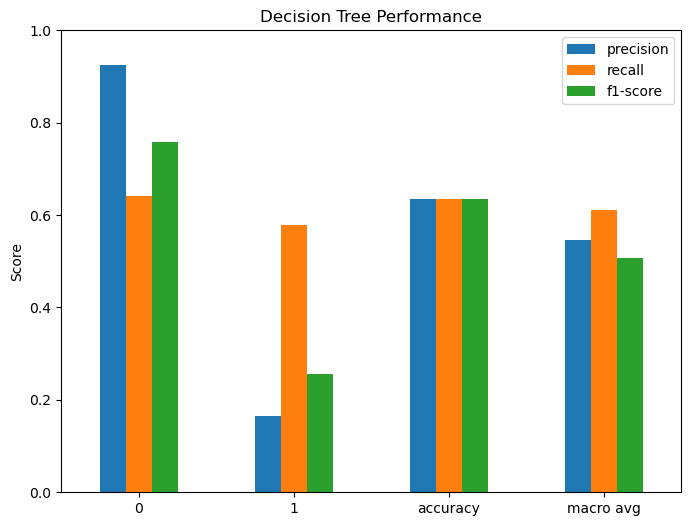

In [199]:
# Showing the scores of f1-score, precision and recall for the decision tree in bar plot.
decision_tree_report = classification_report(y_test, y_decision_tree_pred, output_dict=True)
decision_tree_df = pd.DataFrame(decision_tree_report).transpose().iloc[:-1, :3] 
decision_tree_df.plot(kind="bar", figsize=(8, 6))
plt.title("Decision Tree Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="upper right")


# saving the decision tree results in csv and png to the folder results.
decision_tree_df.to_csv(result_path / "decision_tree_report.csv")
plt.savefig(result_path / "decision_tree_performance.png", dpi=300, bbox_inches="tight")

plt.show()

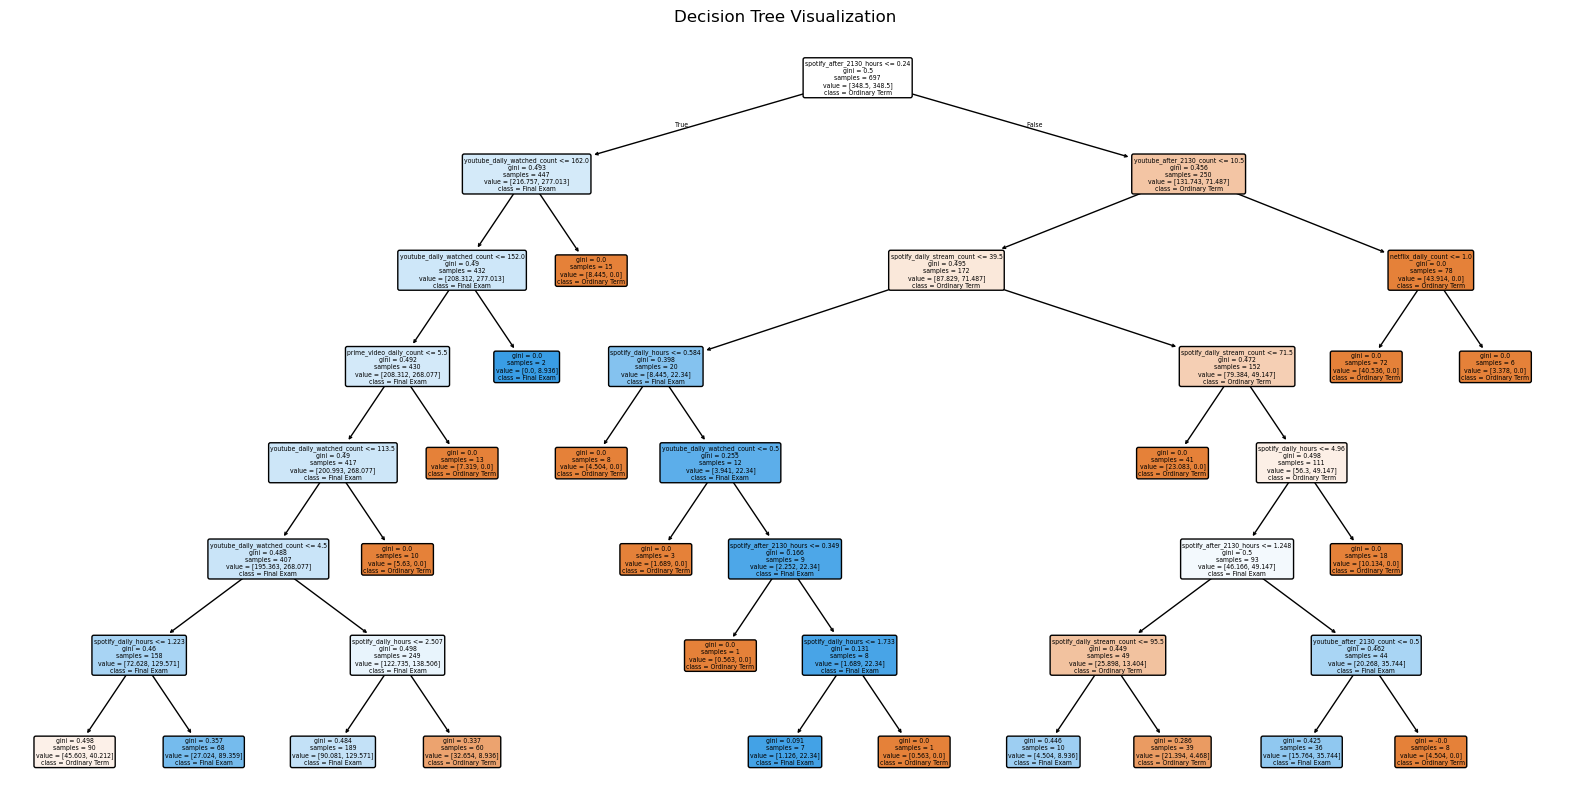

In [200]:
# Adding the decision tree itself, how it decides to split the data based on the features. 
# This will help us understand which features are more important for the model and how it is making its predictions.
#  We can use the plot_tree function from sklearn to visualize the decision tree.
# The tree is constructed based on the best max depth that we get by fine tuning the parameter max depth.
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(best_decision_tree, feature_names=feature_columns, class_names=["Ordinary Term", "Final Exam"], filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.savefig(result_path / "decision_tree_visualization.png", dpi=300, bbox_inches="tight")
plt.show()


Cluster centers:
[[-0.34117211 -0.3144116  -0.33509574 -0.03620566  0.00271632 -0.00462087
   0.0293981   0.01640626 -0.01214849  0.00516301 -0.10439309]
 [ 1.47286497  1.35733787  1.44663284  0.15630247 -0.01172657  0.01994862
  -0.12691375 -0.07082703  0.05244591 -0.02228908  0.45067262]]


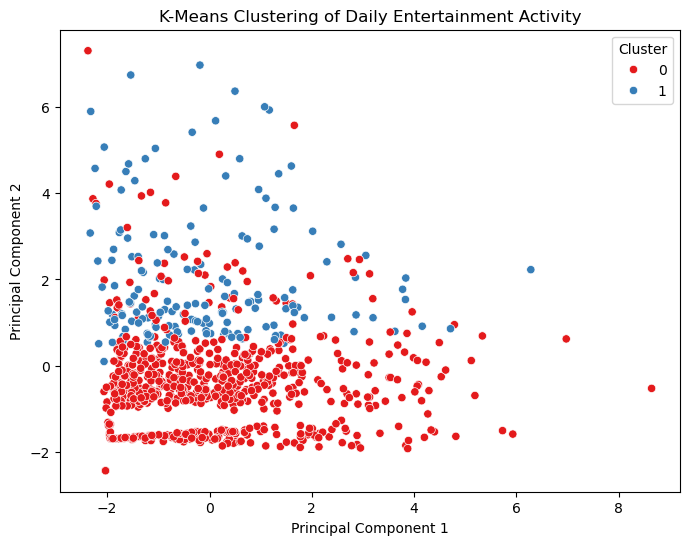

In [201]:
#------------------------------ K MEANS CLUSTERING --------------------------------#
# K means clustering to find patterns in the daily entertainment activity data and see if there are distinct clusters of days based on the entertainment activity features. This can help us understand if there are different


from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# Scaling tthe features before applying k means. 
# since they might be on different scales, we have to make sure they would be working well.
# for example the wages and age example. wages can be in thousand and while age would be in tens.
# If we do not do this than it would give unnecessary weight to the features that are on higher scales, which would lead to a biased clustering result.
scaled_features = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(scaled_features)

print("Cluster centers:")
print(kmeans.cluster_centers_)
#print("Cluster labels:")
#print(kmeans.labels_)

# PCA is a dimensionality reduction technique that allows us to visualize 
# high-dimensional data in a lower-dimensional space while preserving as much of the variance in the data as possible.
# showing how it clusters in the feature space by using the first two principal components.
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_features[:, 0], y=pca_features[:, 1], hue=kmeans.labels_, palette="Set1")
plt.title("K-Means Clustering of Daily Entertainment Activity")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.savefig(result_path / "kmeans_clustering.png", dpi=300, bbox_inches="tight")
plt.show()

Cluster to class mapping:
{0: 0, 1: 0}
K-Means Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       775
           1       0.00      0.00      0.00        97

    accuracy                           0.89       872
   macro avg       0.44      0.50      0.47       872
weighted avg       0.79      0.89      0.84       872



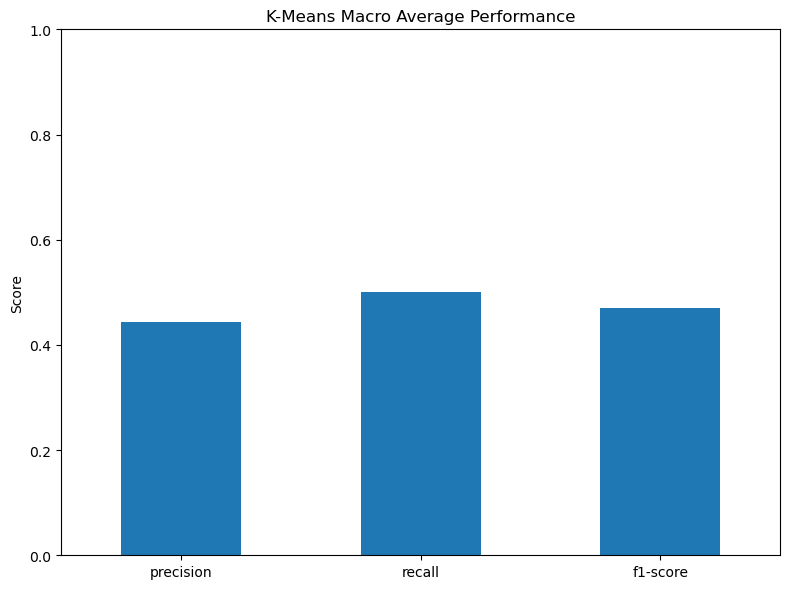

In [202]:
# Showing the macro f1 score, precision and recall scores for the k means clustering 
# by treating one cluster as the final exam period and the other cluster as the ordinary term. 
# This will give us an idea about how well the clusters are separated and how well they correspond to the actual labels of the days.

from sklearn.metrics import classification_report

# Map each cluster to the majority true class inside that cluster
cluster_to_class = (pd.DataFrame({
        "cluster": kmeans.labels_,
        "true_label": y.values})
    .groupby("cluster")["true_label"]
    .agg(lambda labels: labels.value_counts().idxmax())
    .to_dict())

print("Cluster to class mapping:")
print(cluster_to_class)

# Convert cluster labels into predicted class labels
y_kmeans_pred = pd.Series(kmeans.labels_).map(cluster_to_class).values

# Classification report comparing mapped clusters against true labels
kmeans_report = classification_report(
    y,
    y_kmeans_pred,
    output_dict=True,
    zero_division=0
)

print("K-Means Classification Report:")
print(classification_report(y, y_kmeans_pred, zero_division=0))

# Get only macro precision, recall, and f1-score
kmeans_macro_df = (
    pd.DataFrame(kmeans_report)
    .transpose()
    .loc[["macro avg"], ["precision", "recall", "f1-score"]]
)

# Bar plot
kmeans_macro_df.T.plot(kind="bar", figsize=(8, 6), legend=False)

plt.title("K-Means Macro Average Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()

# Save results
kmeans_macro_df.to_csv(result_path / "kmeans_macro_report.csv")

kmeans_report_df = pd.DataFrame(kmeans_report).transpose()
kmeans_report_df.to_csv(result_path / "kmeans_full_report.csv")
plt.savefig(result_path / "kmeans_macro_performance.png", dpi=300, bbox_inches="tight")

plt.show()


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       156
           1       0.12      0.11      0.11        19

    accuracy                           0.82       175
   macro avg       0.51      0.51      0.51       175
weighted avg       0.81      0.82      0.82       175



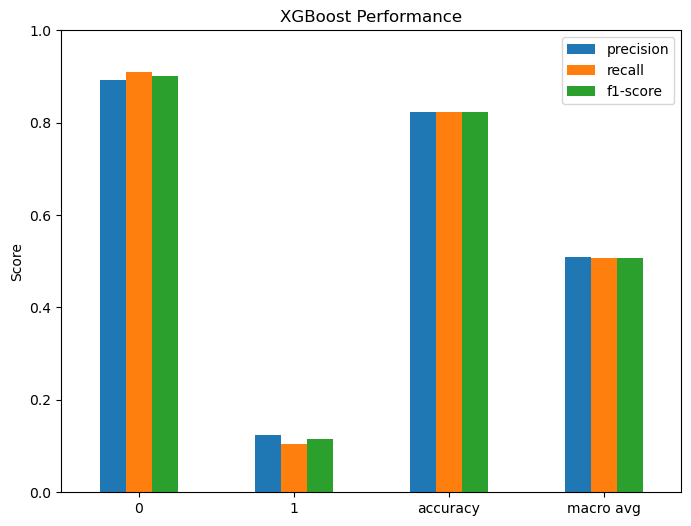

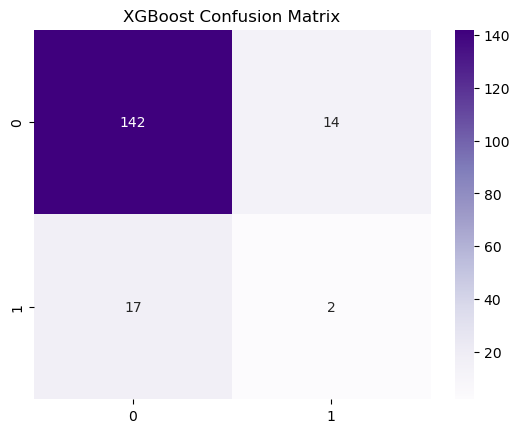

In [203]:
#-------------------------------------XGBOOST CLASSIFIER--------------------------------#
# XGBoost classifier to predict whether a day is in the final exam period or not.


from xgboost import XGBClassifier
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

xgboost_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight)
xgboost_model.fit(X_train, y_train)
y_xgboost_pred = xgboost_model.predict(X_test)
print("XGBoost Classification Report:")
print(classification_report(y_test, y_xgboost_pred))
#Saving the xgboost classification report in csv and png to the folder results.
xgboost_report = classification_report(y_test, y_xgboost_pred, output_dict=True)
xgboost_df = pd.DataFrame(xgboost_report).transpose().iloc[:-1, :3] 
xgboost_df.to_csv(result_path / "xgboost_report.csv")
xgboost_df.plot(kind="bar", figsize=(8, 6))
plt.title("XGBoost Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.savefig(result_path / "xgboost_performance.png", dpi=300, bbox_inches="tight")
plt.show()

# Saving the performance of the xgboost model in csv
xgboost_macro_df = (
    pd.DataFrame(xgboost_report)
    .transpose()
    .loc[["macro avg"], ["precision", "recall", "f1-score"]]
)
xgboost_macro_df.to_csv(result_path / "xgboost_macro_report.csv")

# Heat map for confusion matrix of xgboost model.
plt.title("XGBoost Confusion Matrix")
sns.heatmap(confusion_matrix(y_test, y_xgboost_pred), annot=True, fmt="d", cmap="Purples")
plt.savefig(result_path / "xgboost_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       156
           1       0.00      0.00      0.00        19

    accuracy                           0.87       175
   macro avg       0.44      0.49      0.46       175
weighted avg       0.79      0.87      0.83       175



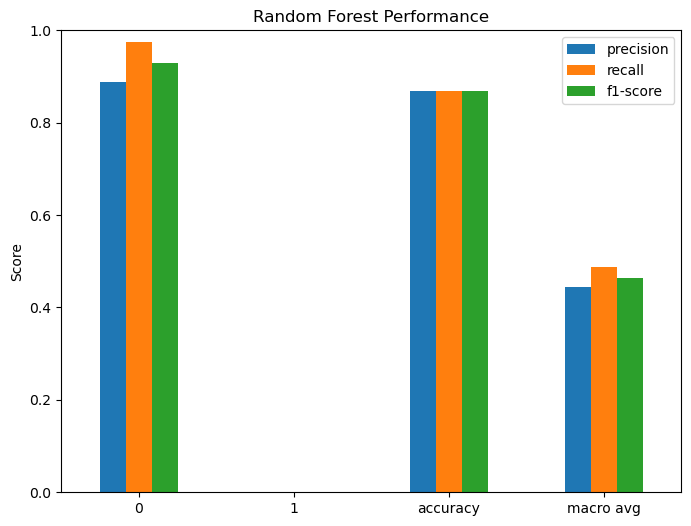

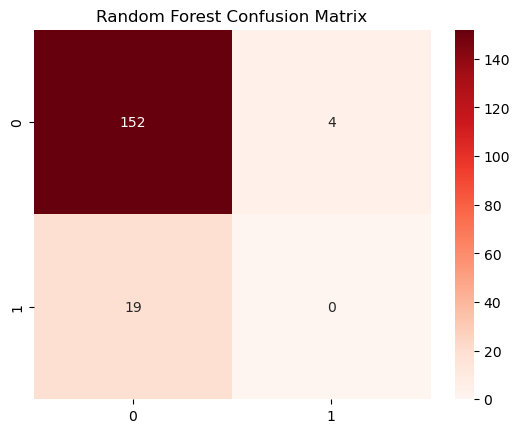

In [204]:
#------------------------------------RANDOM FOREST CLASSIFIER--------------------------------#
# Random forest classifier to predict whether a day is in the final exam period or not based on
# It internally uses a ensemble method, where there are multiple decision trees that are trained on different subsets of the data and features,
#  and then the final prediction is made by aggregating the predictions of all the individual trees.


from sklearn.ensemble import RandomForestClassifier
random_forest_model = RandomForestClassifier(random_state=42, class_weight="balanced", n_estimators=100)
random_forest_model.fit(X_train, y_train)
y_random_forest_pred = random_forest_model.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_random_forest_pred))


# Saving the random forest classification report in csv and png to the folder results.
random_forest_report = classification_report(y_test, y_random_forest_pred, output_dict=True)
random_forest_df = pd.DataFrame(random_forest_report).transpose().iloc[:-1, :3] 
random_forest_df.to_csv(result_path / "random_forest_report.csv")
random_forest_df.plot(kind="bar", figsize=(8, 6))
plt.title("Random Forest Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.savefig(result_path / "random_forest_performance.png", dpi=300, bbox_inches="tight")
plt.show()

# Random forest heat map
plt.title("Random Forest Confusion Matrix")
sns.heatmap(confusion_matrix(y_test, y_random_forest_pred), annot=True, fmt="d", cmap="Reds")
plt.savefig(result_path / "random_forest_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show() 

In [205]:
#----------------------------------ENSEMBLE MODEL--------------------------------#
# Ensemble model to combine the predictions of the logistic regression, decision tree, xg
#boost and random forest models to see if we can improve the performance with adding strenghts of different models.
from sklearn.ensemble import VotingClassifier
ensemble_model = VotingClassifier(
    estimators=[
        ("logistic_regression", log_reg_pipeline),
        ("decision_tree", best_decision_tree),
        ("xgboost", xgboost_model),
        ("random_forest", random_forest_model)
    ],
    voting="soft"
)
ensemble_model.fit(X_train, y_train)
y_ensemble_pred = ensemble_model.predict(X_test)
print("Ensemble Model Classification Report:")
print(classification_report(y_test, y_ensemble_pred))

Ensemble Model Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       156
           1       0.15      0.11      0.12        19

    accuracy                           0.84       175
   macro avg       0.52      0.52      0.52       175
weighted avg       0.81      0.84      0.83       175



In [206]:
# Printing out all results in a table to compare the performance of all the models we have implemented.
results_df = pd.DataFrame({
    "Model": ["Dummy Classifier", "Logistic Regression", "Decision Tree", "XGBoost", "Random Forest", "Ensemble Model"],
    "Precision": [
        dummy_report["macro avg"]["precision"],
        log_reg_report["macro avg"]["precision"],
        decision_tree_report["macro avg"]["precision"],
        xgboost_report["macro avg"]["precision"],
        random_forest_report["macro avg"]["precision"],
        classification_report(y_test, y_ensemble_pred, output_dict=True)["macro avg"]["precision"]
    ],
    "Recall": [
        dummy_report["macro avg"]["recall"],
        log_reg_report["macro avg"]["recall"],
        decision_tree_report["macro avg"]["recall"],
        xgboost_report["macro avg"]["recall"],
        random_forest_report["macro avg"]["recall"],
        classification_report(y_test, y_ensemble_pred, output_dict=True)["macro avg"]["recall"]
    ],
    "F1-Score": [
        dummy_report["macro avg"]["f1-score"],
        log_reg_report["macro avg"]["f1-score"],
        decision_tree_report["macro avg"]["f1-score"],
        xgboost_report["macro avg"]["f1-score"],
        random_forest_report["macro avg"]["f1-score"],
        classification_report(y_test, y_ensemble_pred, output_dict=True)["macro avg"]["f1-score"]
    ]
})

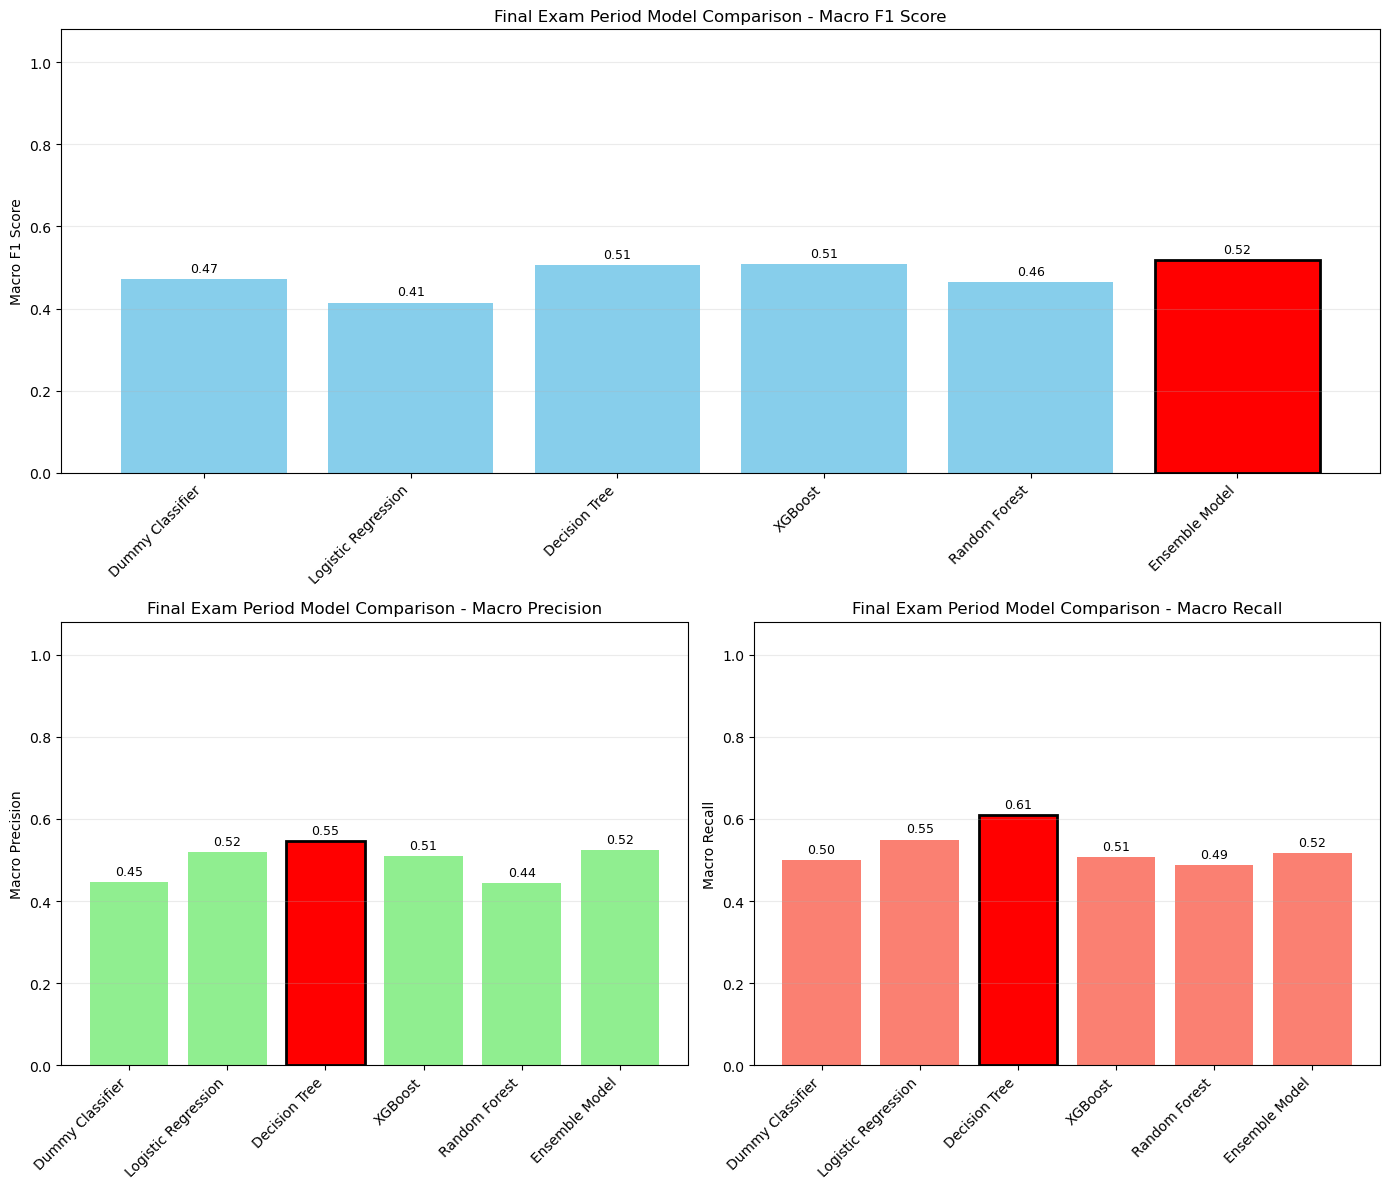

/var/folders/bg/1f1k786920g5016jzpkv6dxc0000gn/T/ipykernel_1869/2405227030.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="F1-Score", data=results_df, palette="Set2")


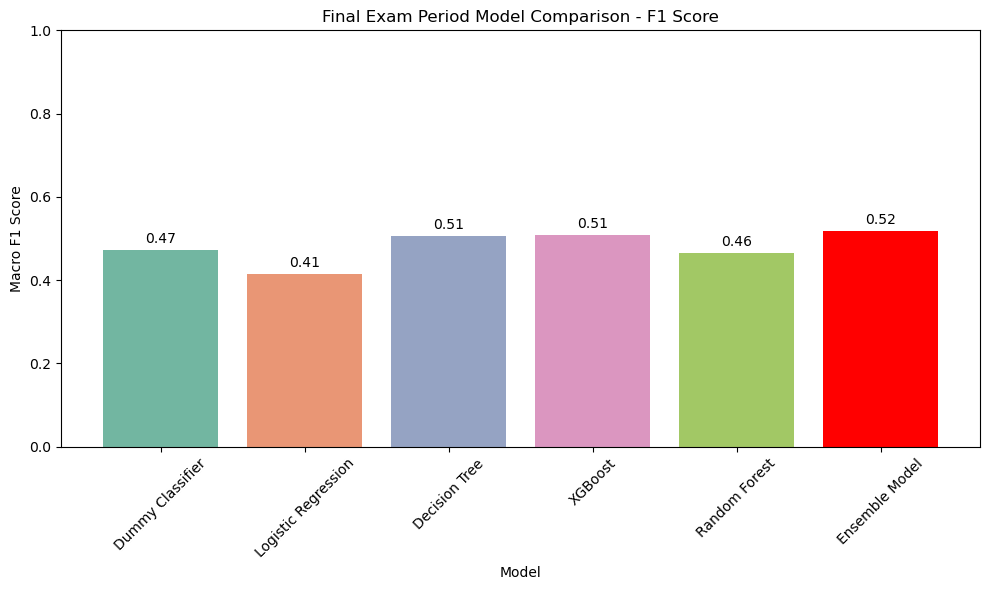

/var/folders/bg/1f1k786920g5016jzpkv6dxc0000gn/T/ipykernel_1869/2405227030.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Precision", data=results_df, palette="Set2")


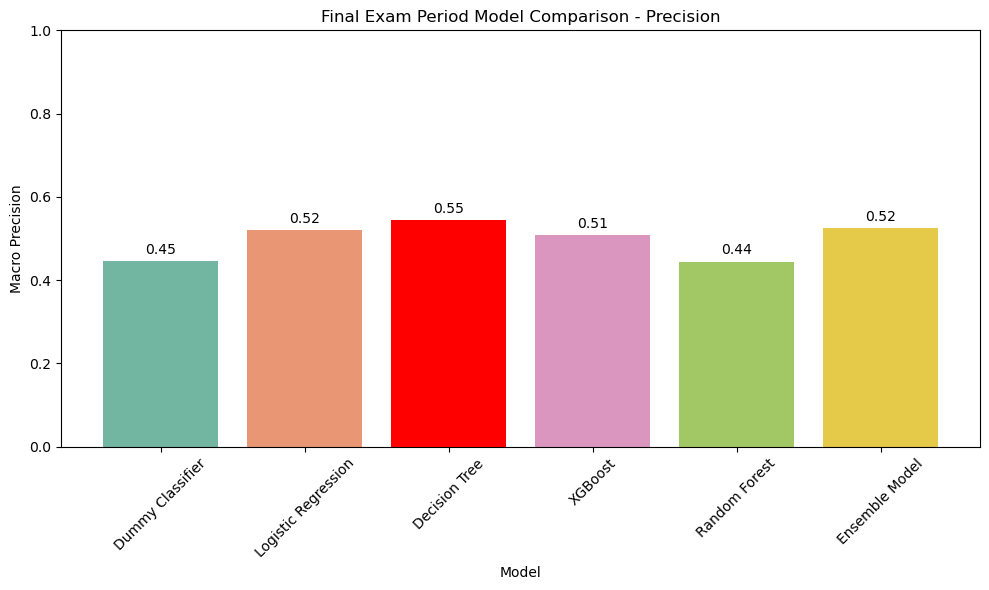

/var/folders/bg/1f1k786920g5016jzpkv6dxc0000gn/T/ipykernel_1869/2405227030.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Recall", data=results_df, palette="Set2")


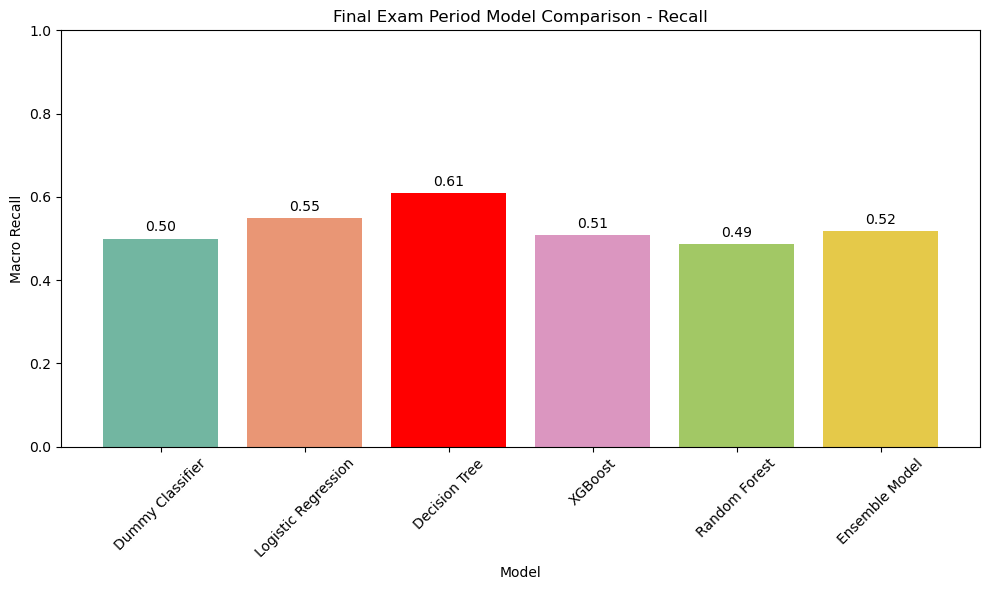

In [207]:
# Saving the final exam period results for all the models.
# First graph shows all three metrics together, then separate graphs show each metric clearly.

results_df.to_csv(result_path / "model_comparison.csv", index=False)

fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(2, 2)

ax_f1 = fig.add_subplot(gs[0, :])
ax_precision = fig.add_subplot(gs[1, 0])
ax_recall = fig.add_subplot(gs[1, 1])

x = np.arange(len(results_df["Model"]))
models = results_df["Model"]

def plot_metric(ax, metric, title, ylabel, color):
    bars = ax.bar(x, results_df[metric], color=color)

    best_index = results_df[metric].idxmax()
    bars[best_index].set_color("red")
    bars[best_index].set_edgecolor("black")
    bars[best_index].set_linewidth(2)

    for index, value in enumerate(results_df[metric]):
        ax.text(index, value + 0.01, f"{value:.2f}", ha="center", va="bottom", fontsize=9)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.08)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.25)

plot_metric(ax_f1, "F1-Score", "Final Exam Period Model Comparison - Macro F1 Score", "Macro F1 Score", "skyblue")
plot_metric(ax_precision, "Precision", "Final Exam Period Model Comparison - Macro Precision", "Macro Precision", "lightgreen")
plot_metric(ax_recall, "Recall", "Final Exam Period Model Comparison - Macro Recall", "Macro Recall", "salmon")

plt.tight_layout()
plt.savefig(result_path / "model_comparison_all_metrics.png", dpi=300, bbox_inches="tight")
plt.show()


# F1 score comparison
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="F1-Score", data=results_df, palette="Set2")
plt.title("Final Exam Period Model Comparison - F1 Score")
plt.ylabel("Macro F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)

best_model_index = results_df["F1-Score"].idxmax()
plt.bar(best_model_index, results_df.loc[best_model_index, "F1-Score"], color="red")

for index, row in results_df.iterrows():
    plt.text(index, row["F1-Score"] + 0.01, f"{row['F1-Score']:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(result_path / "model_comparison_f1_score.png", dpi=300, bbox_inches="tight")
plt.show()


# Precision comparison
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Precision", data=results_df, palette="Set2")
plt.title("Final Exam Period Model Comparison - Precision")
plt.ylabel("Macro Precision")
plt.ylim(0, 1)
plt.xticks(rotation=45)

best_model_index = results_df["Precision"].idxmax()
plt.bar(best_model_index, results_df.loc[best_model_index, "Precision"], color="red")

for index, row in results_df.iterrows():
    plt.text(index, row["Precision"] + 0.01, f"{row['Precision']:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(result_path / "model_comparison_precision.png", dpi=300, bbox_inches="tight")
plt.show()


# Recall comparison
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Recall", data=results_df, palette="Set2")
plt.title("Final Exam Period Model Comparison - Recall")
plt.ylabel("Macro Recall")
plt.ylim(0, 1)
plt.xticks(rotation=45)

best_model_index = results_df["Recall"].idxmax()
plt.bar(best_model_index, results_df.loc[best_model_index, "Recall"], color="red")

for index, row in results_df.iterrows():
    plt.text(index, row["Recall"] + 0.01, f"{row['Recall']:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(result_path / "model_comparison_recall.png", dpi=300, bbox_inches="tight")
plt.show()


In [208]:
#-------------------------------- ACADEMICAL ML METHOD ENDS-----------------------------------#

In [209]:
#--------------------------------SUMMER WORK PERIOD*-----------------------------------#

In [210]:
#------------------------ SUMMER WORK ML PREPARATION ------------------------#

summer_ml_data = combined_daily[
    combined_daily["analysis_period"].isin(["ordinary_term", "summer_work_period"])
].copy()

summer_ml_data["is_summer_work_day"] = (
    summer_ml_data["analysis_period"] == "summer_work_period"
).astype(int)

summer_feature_columns = [
    "youtube_daily_watched_count",
    "youtube_daily_search_count",
    "youtube_after_2130_count",
    "youtube_after_2130_share",
    "spotify_daily_hours",
    "spotify_daily_stream_count",
    "spotify_daily_unique_tracks",
    "spotify_after_2130_hours",
    "spotify_after_2130_hour_share",
    "netflix_daily_count",
    "prime_video_daily_count",
    "netflix_prime_daily_count",
    "daily_distinct_entertainment_platform_count",
]

X_summer = summer_ml_data[summer_feature_columns].copy()
y_summer = summer_ml_data["is_summer_work_day"].copy()

print("Summer ML data shape:", summer_ml_data.shape)
print("Target distribution:")
print(summer_ml_data["analysis_period"].value_counts())
print("Feature summary:")
print(X_summer.describe().T)

Summer ML data shape: (979, 30)
Target distribution:
analysis_period
ordinary_term         775
summer_work_period    204
Name: count, dtype: int64
Feature summary:
                                             count       mean        std  min  \
youtube_daily_watched_count                  979.0  25.313585  44.277046  0.0   
youtube_daily_search_count                   979.0   1.680286   2.601111  0.0   
youtube_after_2130_count                     979.0  12.065373  27.492587  0.0   
youtube_after_2130_share                     979.0   0.239187   0.342533  0.0   
spotify_daily_hours                          979.0   1.953930   1.570987  0.0   
spotify_daily_stream_count                   979.0  91.483146  92.437269  0.0   
spotify_daily_unique_tracks                  979.0  72.897855  70.034112  0.0   
spotify_after_2130_hours                     979.0   0.387595   0.593699  0.0   
spotify_after_2130_hour_share                979.0   0.206844   0.290660  0.0   
netflix_daily_count       

In [211]:
X_summer_train, X_summer_test, y_summer_train, y_summer_test = train_test_split(
    X_summer,
    y_summer,
    test_size=0.2,
    random_state=42,
    stratify=y_summer
)
result_path = project_root / "MachineLearning/results/ACADEMICAL_PERIOD"

summerpath = project_root / "MachineLearning/results/SUMMER_WORK_PERIOD"



#-------------------------SUMMER WORK ML MODELS-----------------------#
# We will implement the same machine learning models for the summer work period as we did for the final exam period, which are:
# - Dummy Classifier
# - Logistic Regression
# - Decision Tree Classifier
# - XGBoost Classifier
# - Random Forest Classifier
# - Ensemble Model

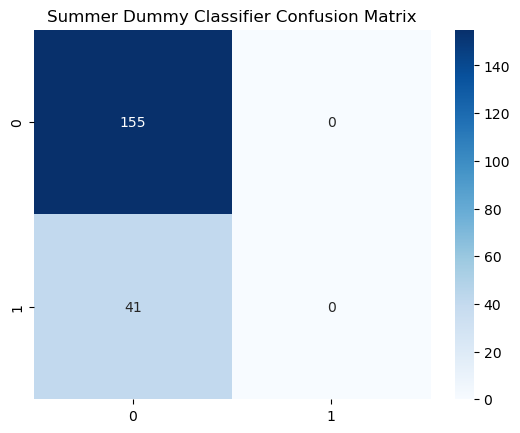

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


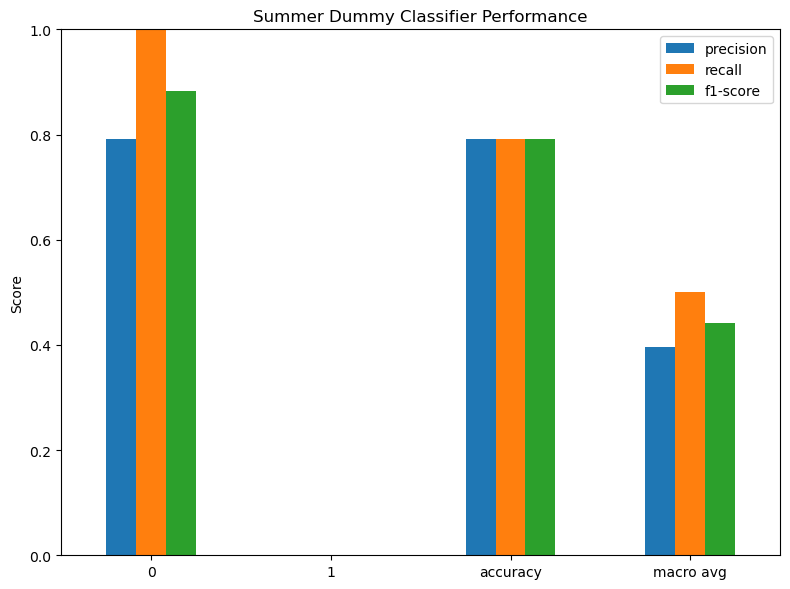

In [212]:
#-------------------------------DUMMY CLASSIFIER-------------------------------#
summer_dummy_clf = DummyClassifier(strategy="most_frequent", random_state=42)
summer_dummy_clf.fit(X_summer_train, y_summer_train)
y_summer_dummy_pred = summer_dummy_clf.predict(X_summer_test)
plt.title("Summer Dummy Classifier Confusion Matrix")
sns.heatmap(confusion_matrix(y_summer_test, y_summer_dummy_pred), annot=True, fmt="d", cmap="Blues")
plt.savefig(summerpath / "summer_dummy_classifier_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

summer_dummy_report = classification_report(y_summer_test, y_summer_dummy_pred, output_dict=True)
summer_dummy_df = pd.DataFrame(summer_dummy_report).transpose().iloc[:-1, :3]
summer_dummy_df.to_csv(summerpath / "summer_dummy_classifier_report.csv")
summer_dummy_df.plot(kind="bar", figsize=(8, 6))
plt.title("Summer Dummy Classifier Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(summerpath / "summer_dummy_classifier_performance.png", dpi=300, bbox_inches="tight")
plt.show()

Summer Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.59      0.72       155
           1       0.35      0.85      0.50        41

    accuracy                           0.64       196
   macro avg       0.65      0.72      0.61       196
weighted avg       0.82      0.64      0.68       196



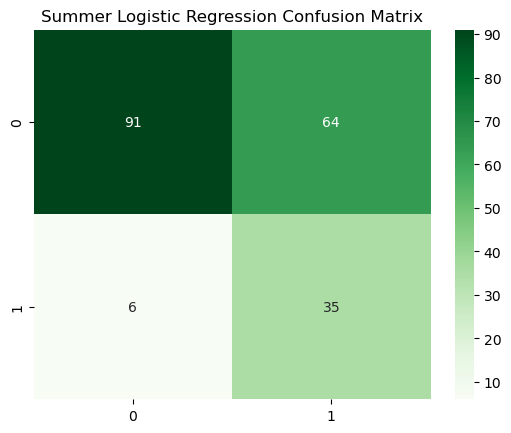

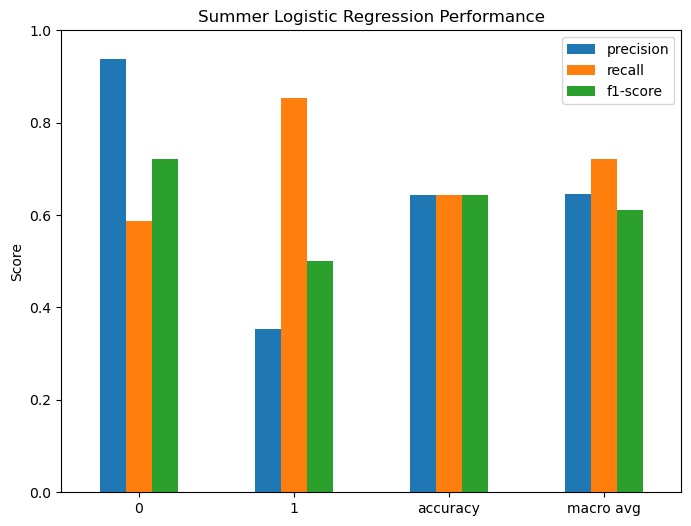

In [213]:
# -------------------------------LOGISTIC REGRESSION-------------------------------#

# Logistic regression model to predict whether a day is in the summer work period or not based on the daily entertainment
#  activity features. We will use a pipeline to standardize the features and then fit the logistic regression model
# , similar to what we did for the final exam period.



# Model decleration
summer_log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
])
summer_log_reg_pipeline.fit(X_summer_train, y_summer_train)
y_summer_log_reg_pred = summer_log_reg_pipeline.predict(X_summer_test)
print("Summer Logistic Regression Classification Report:")
print(classification_report(y_summer_test, y_summer_log_reg_pred))
# Confusion matrix heat map for the logistic regression model for the summer work period.
plt.title("Summer Logistic Regression Confusion Matrix")
sns.heatmap(confusion_matrix(y_summer_test, y_summer_log_reg_pred), annot=True, fmt="d", cmap="Greens")
plt.savefig(summerpath / "summer_logistic_regression_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


# showing the results of the logistic regression model for the summer work period in a bar plot for the macro f1 score, precision and recall scores.
summer_log_reg_report = classification_report(y_summer_test, y_summer_log_reg_pred, output_dict=True)
summer_log_reg_df = pd.DataFrame(summer_log_reg_report).transpose().iloc[:-1, :3]
summer_log_reg_df.to_csv(summerpath / "summer_logistic_regression_report.csv")
summer_log_reg_df.plot(kind="bar", figsize=(8, 6))
plt.title("Summer Logistic Regression Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.savefig(summerpath / "summer_logistic_regression_performance.png", dpi=300, bbox_inches="tight")
plt.show()

Max Depth: 2, F1 Score: 0.6086
Max Depth: 3, F1 Score: 0.5982
Max Depth: 4, F1 Score: 0.6241
Max Depth: 5, F1 Score: 0.6274
Max Depth: 6, F1 Score: 0.6447
Max Depth: 7, F1 Score: 0.6491
Max Depth: 8, F1 Score: 0.6877
Max Depth: 9, F1 Score: 0.6714
Max Depth: 10, F1 Score: 0.6824
Best Max Depth: 8, Best F1 Score: 0.6877
Summer Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.63      0.75       155
           1       0.36      0.80      0.50        41

    accuracy                           0.66       196
   macro avg       0.64      0.72      0.62       196
weighted avg       0.81      0.66      0.69       196



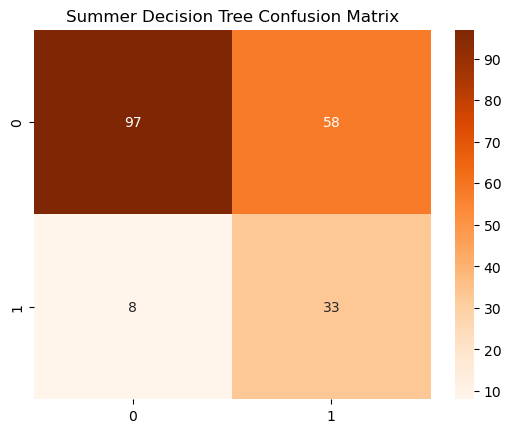

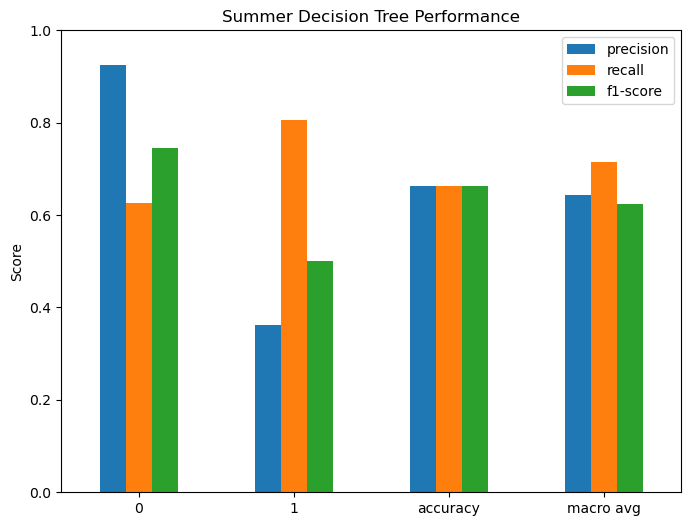

In [214]:
# -------------------------------DECISION TREE CLASSIFIER-------------------------------#
# Decision tree classifier to predict whether a day is in the summer work period or not based on the daily entertainment
#  activity features. We will fine tune the max_depth hyperparameter of the decision tree model using a validation set,
#  similar to what we did for the final exam period.


x_summer_train_sub, x_summer_val, y_summer_train_sub, y_summer_val = train_test_split(
    X_summer_train,
    y_summer_train,
    test_size=0.25,
    random_state=42,
    stratify=y_summer_train)

max_depth_values = [2, 3, 4, 5, 6 , 7, 8, 9, 10]
best_f1_score = 0
best_max_depth = None
for max_depth in max_depth_values:
    model = DecisionTreeClassifier(class_weight="balanced", random_state=42, max_depth=max_depth)
    model.fit(x_summer_train_sub, y_summer_train_sub)
    y_val_pred = model.predict(x_summer_val)
    report = classification_report(y_summer_val, y_val_pred, output_dict=True)
    f1_score = report["macro avg"]["f1-score"]
    
    print(f"Max Depth: {max_depth}, F1 Score: {f1_score:.4f}")
    
    if f1_score > best_f1_score:
        best_f1_score = f1_score
        best_max_depth = max_depth
print(f"Best Max Depth: {best_max_depth}, Best F1 Score: {best_f1_score:.4f}")
best_summer_decision_tree = DecisionTreeClassifier(class_weight="balanced", random_state=42, max_depth=best_max_depth)
best_summer_decision_tree.fit(X_summer_train, y_summer_train)
y_summer_decision_tree_pred = best_summer_decision_tree.predict(X_summer_test)
print("Summer Decision Tree Classification Report:")
print(classification_report(y_summer_test, y_summer_decision_tree_pred))

# Confusion matrix heat map for the decision tree model for the summer work period.
plt.title("Summer Decision Tree Confusion Matrix")
sns.heatmap(confusion_matrix(y_summer_test, y_summer_decision_tree_pred), annot=True, fmt="d", cmap="Oranges")
plt.savefig(summerpath / "summer_decision_tree_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()



# Saving the classicifaction report results for the decision tree model
summer_decision_tree_report = classification_report(y_summer_test, y_summer_decision_tree_pred, output_dict=True)
summer_decision_tree_df = pd.DataFrame(summer_decision_tree_report).transpose().iloc[:-1, :3]
summer_decision_tree_df.to_csv(summerpath / "summer_decision_tree_report.csv")
summer_decision_tree_df.plot(kind="bar", figsize=(8, 6))
plt.title("Summer Decision Tree Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.savefig(summerpath / "summer_decision_tree_performance.png", dpi=300, bbox_inches="tight")
plt.show()

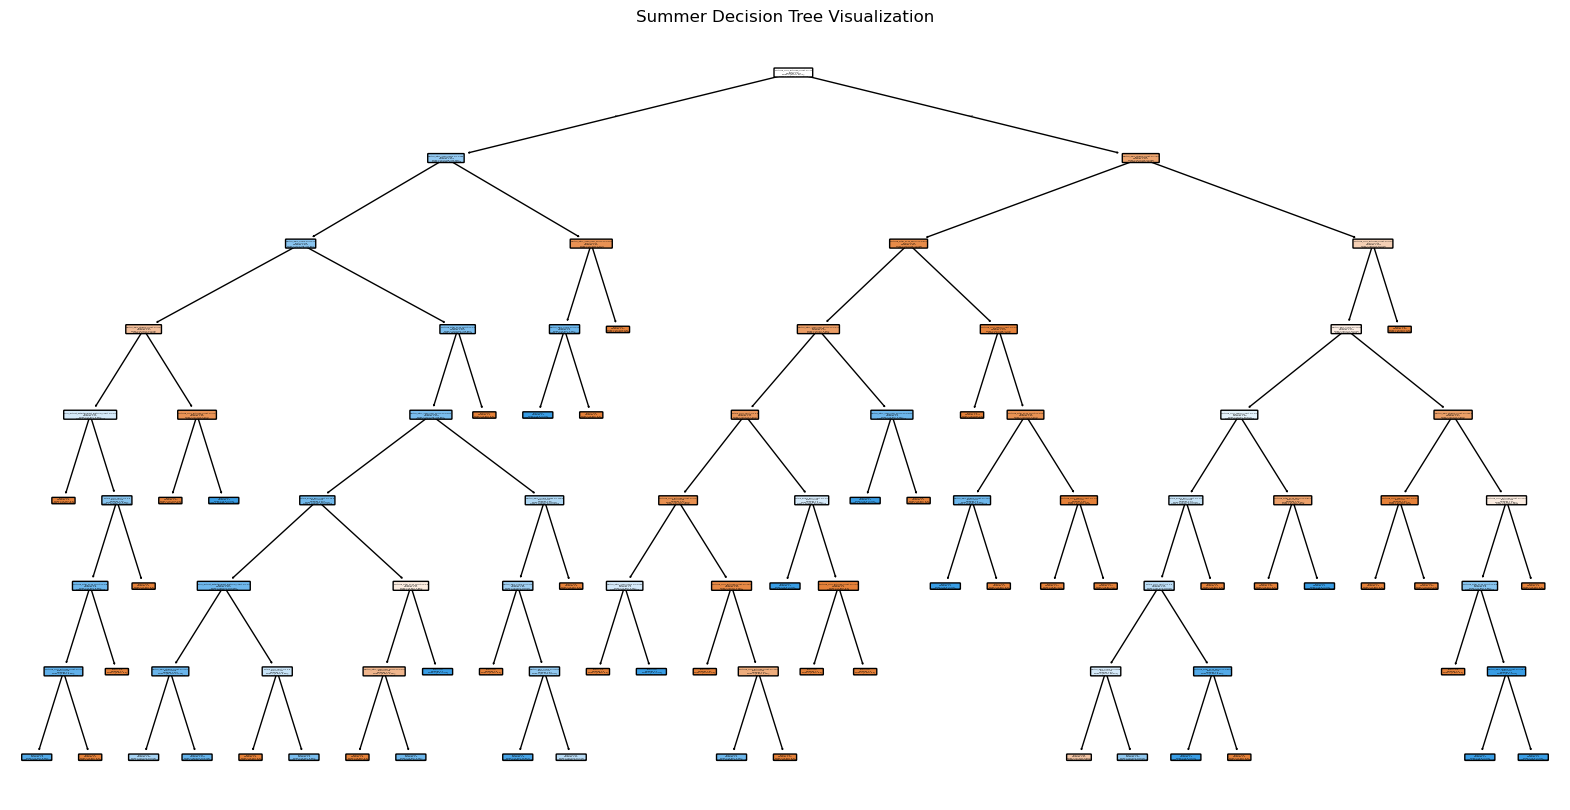

In [215]:
# Summer decision tree  
plt.figure(figsize=(20, 10))
plot_tree(best_summer_decision_tree, feature_names=summer_feature_columns, class_names=["Ordinary Term", "Summer Work Period"], filled=True, rounded=True)
plt.title("Summer Decision Tree Visualization")
plt.savefig(summerpath / "summer_decision_tree_visualization.png", dpi=300, bbox_inches="tight")
plt.show()

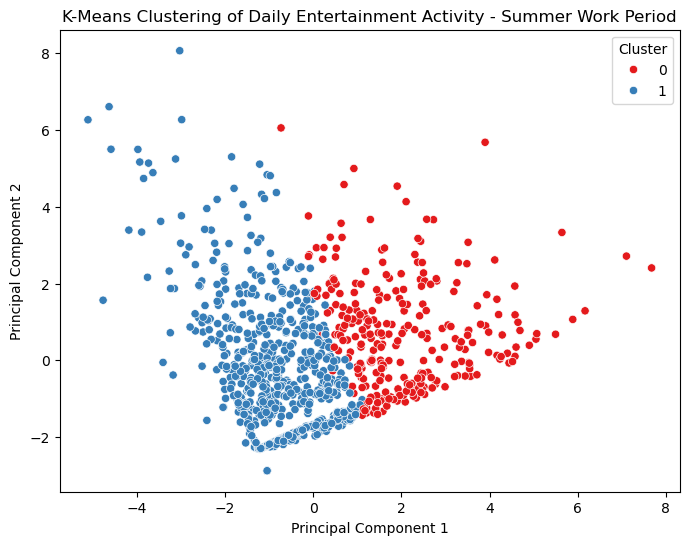

K-Means Summer Work Period Classification Report:
              precision    recall  f1-score   support

           0       0.79      1.00      0.88       775
           1       0.00      0.00      0.00       204

    accuracy                           0.79       979
   macro avg       0.40      0.50      0.44       979
weighted avg       0.63      0.79      0.70       979



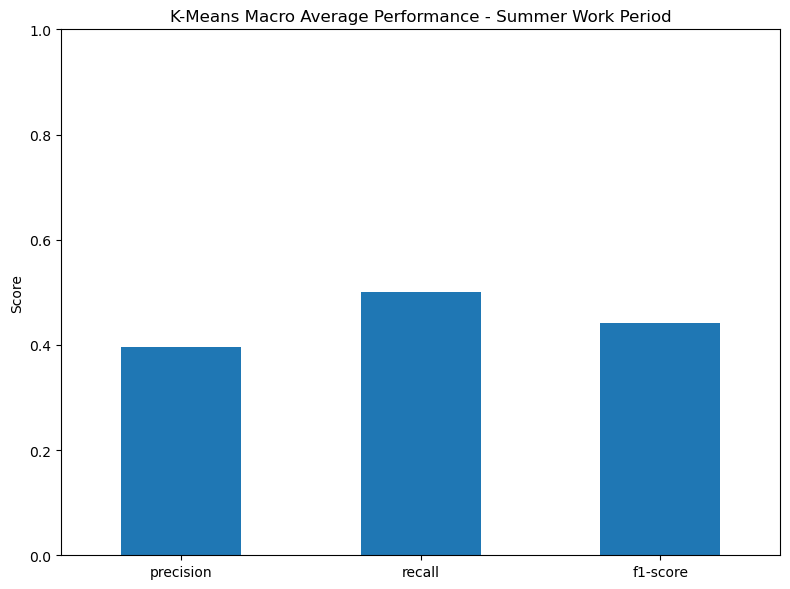

In [216]:
#------------------------------- KMEANS CLUSTERING-------------------------------#
# K means clustering to find patterns in the daily entertainment activity data for the summer work period
#  and see if there are distinct clusters of days based on the entertainment activity features, similar to what we had in the previous ml iöplementation.



# Model feature declaraiton,scaling and fitting the model.
scaled_summer_features = StandardScaler().fit_transform(X_summer)
kmeans_summer = KMeans(n_clusters=2, random_state=42)
kmeans_summer.fit(scaled_summer_features)


# PCA visualization for the k means clustering for the summer work period.
pca_summer = PCA(n_components=2)
pca_summer_features = pca_summer.fit_transform(scaled_summer_features)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_summer_features[:, 0], y=pca_summer_features[:, 1], hue=kmeans_summer.labels_, palette="Set1")
plt.title("K-Means Clustering of Daily Entertainment Activity - Summer Work Period")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.savefig(summerpath / "kmeans_summer_clustering.png", dpi=300, bbox_inches="tight")
plt.show()


# Classification report saving for k means. 
cluster_to_class_summer = (pd.DataFrame({
        "cluster": kmeans_summer.labels_,
        "true_label": y_summer.values})
    .groupby("cluster")["true_label"]
    .agg(lambda labels: labels.value_counts().idxmax())
    .to_dict())
y_kmeans_summer_pred = pd.Series(kmeans_summer.labels_).map(cluster_to_class_summer).values
kmeans_summer_report = classification_report(
    y_summer,
    y_kmeans_summer_pred,
    output_dict=True,
    zero_division=0
)
print("K-Means Summer Work Period Classification Report:")
print(classification_report(y_summer, y_kmeans_summer_pred, zero_division=0))
kmeans_summer_macro_df = (
    pd.DataFrame(kmeans_summer_report)
    .transpose()
    .loc[["macro avg"], ["precision", "recall", "f1-score"]]
)
kmeans_summer_macro_df.to_csv(summerpath / "kmeans_summer_macro_report.csv")
kmeans_summer_report_df = pd.DataFrame(kmeans_summer_report).transpose()
kmeans_summer_report_df.to_csv(summerpath / "kmeans_summer_full_report.csv")
kmeans_summer_macro_df.T.plot(kind="bar", figsize=(8, 6), legend=False)
plt.title("K-Means Macro Average Performance - Summer Work Period")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(summerpath / "kmeans_summer_macro_performance.png", dpi=300, bbox_inches="tight")
plt.show()

Summer XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86       155
           1       0.47      0.49      0.48        41

    accuracy                           0.78       196
   macro avg       0.66      0.67      0.67       196
weighted avg       0.78      0.78      0.78       196



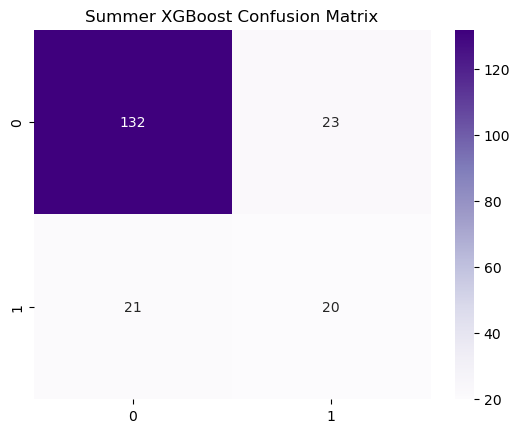

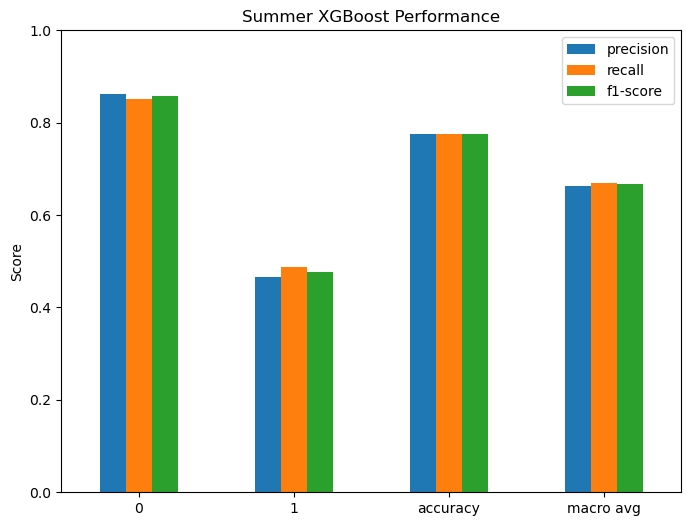

In [217]:
# ------------------------------xgboost classifier------------------------------#
# XGBoost classifier to predict whether a day is in the summer work period or not based
# on the daily entertainment activity features. We will use the same approach as we did for the final exam period, 
# where we will calculate the scale_pos_weight parameter based on the class imbalance in the training data.


# Calculating the scale_pos_weight parameter for the xgboost model based on the class imbalance
#  in the training data for the summer work period. This will help the xgboost model to handle 
# the class imbalance and improve its performance on the minority class, which is the summer work period in our case.
negative_count = (y_summer_train == 0).sum()
positive_count = (y_summer_train == 1).sum()
scale_pos_weight = negative_count / positive_count

# model decleration and fitting the xgboost model for the summer work period.
summer_xgboost_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)
summer_xgboost_model.fit(X_summer_train, y_summer_train)
y_summer_xgboost_pred = summer_xgboost_model.predict(X_summer_test)
print("Summer XGBoost Classification Report:")
print(classification_report(y_summer_test, y_summer_xgboost_pred))
# Confusion matrix heat map for the xgboost model for the summer work period.
plt.title("Summer XGBoost Confusion Matrix")
sns.heatmap(confusion_matrix(y_summer_test, y_summer_xgboost_pred), annot=True, fmt="d", cmap="Purples")
plt.savefig(summerpath / "summer_xgboost_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# Saving the classification report results for the xgboost model for the summer work period.
summer_xgboost_report = classification_report(y_summer_test, y_summer_xgboost_pred, output_dict=True)
summer_xgboost_df = pd.DataFrame(summer_xgboost_report).transpose().iloc[:-1, :3]
summer_xgboost_df.to_csv(summerpath / "summer_xgboost_report.csv")
summer_xgboost_df.plot(kind="bar", figsize=(8, 6))
plt.title("Summer XGBoost Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.savefig(summerpath / "summer_xgboost_performance.png", dpi=300, bbox_inches="tight")
plt.show()

Summer Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       155
           1       0.43      0.29      0.35        41

    accuracy                           0.77       196
   macro avg       0.63      0.59      0.60       196
weighted avg       0.74      0.77      0.75       196



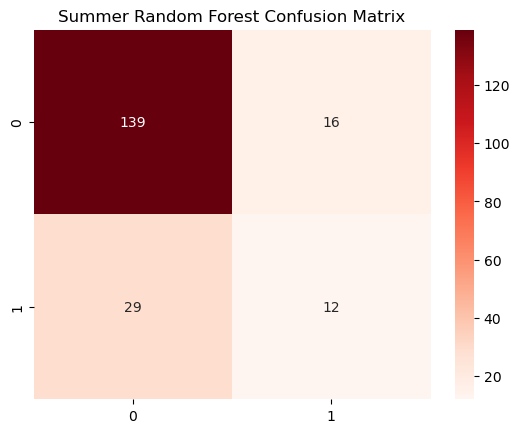

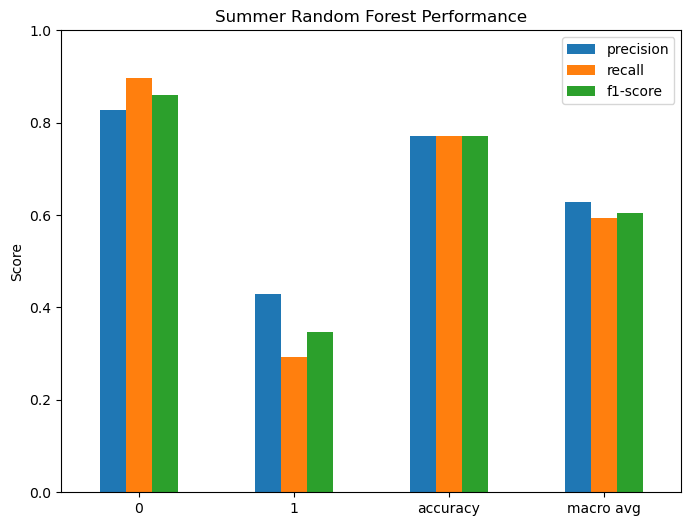

In [218]:
#---------------------------------RANDOM FOREST CLASSIFIER------------------------------#
# Random forest classifier to predict whether a day is in the summer work period or not based on
# the daily entertainment activity features. We will use the same approach as we did for the final exam period, 
# where we will set the class_weight parameter to "balanced" to handle the class imbalance in the training data 
# for the summer work period


summer_random_forest_model = RandomForestClassifier(random_state=42, class_weight="balanced", n_estimators=100)
summer_random_forest_model.fit(X_summer_train, y_summer_train)
y_summer_random_forest_pred = summer_random_forest_model.predict(X_summer_test)
print("Summer Random Forest Classification Report:")
print(classification_report(y_summer_test, y_summer_random_forest_pred))  


# Confusion matrix heat map for the random forest model for the summer work period.
plt.title("Summer Random Forest Confusion Matrix")
sns.heatmap(confusion_matrix(y_summer_test, y_summer_random_forest_pred), annot=True, fmt="d", cmap="Reds")
plt.savefig(summerpath / "summer_random_forest_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


# Saving the classification report results for the random forest model for the summer work period.
summer_random_forest_report = classification_report(y_summer_test, y_summer_random_forest_pred, output_dict=True)
summer_random_forest_df = pd.DataFrame(summer_random_forest_report).transpose().iloc[:-1, :3]
summer_random_forest_df.to_csv(summerpath / "summer_random_forest_report.csv")
summer_random_forest_df.plot(kind="bar", figsize=(8, 6))
plt.title("Summer Random Forest Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.savefig(summerpath / "summer_random_forest_performance.png", dpi=300, bbox_inches="tight")
plt.show()

Summer Ensemble Model Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.83       155
           1       0.40      0.49      0.44        41

    accuracy                           0.74       196
   macro avg       0.63      0.65      0.64       196
weighted avg       0.76      0.74      0.75       196



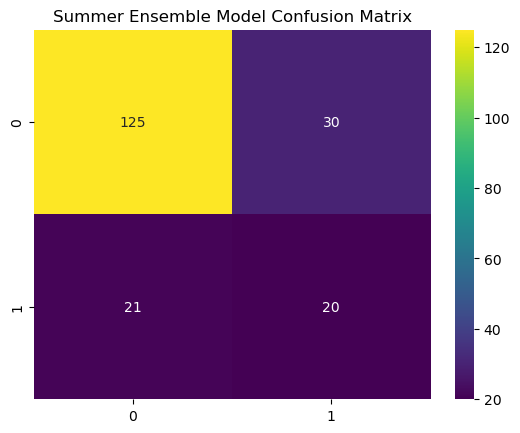

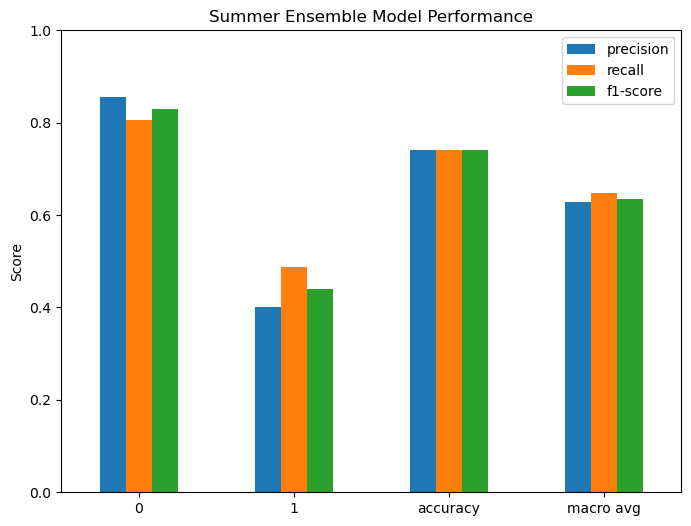

In [219]:
#-------------------------------- ENSEMBLE MODEL------------------------------#
# Ensemble model to combine the predictions of the logistic regression, decision tree, xgboost and random forest models 
# to see if we can improve the performance with adding strenghts of different models for to increase the macro f1 score


summer_ensemble_model = VotingClassifier(
    estimators=[
        ("logistic_regression", summer_log_reg_pipeline),
        ("decision_tree", best_summer_decision_tree),
        ("xgboost", summer_xgboost_model),
        ("random_forest", summer_random_forest_model),
    ],
    voting="soft"
)
summer_ensemble_model.fit(X_summer_train, y_summer_train)
y_summer_ensemble_pred = summer_ensemble_model.predict(X_summer_test)
print("Summer Ensemble Model Classification Report:")
print(classification_report(y_summer_test, y_summer_ensemble_pred))


# Confusion matrix heat map for the ensemble model for the summer work period.
plt.title("Summer Ensemble Model Confusion Matrix")
sns.heatmap(confusion_matrix(y_summer_test, y_summer_ensemble_pred), annot=True, fmt="d", cmap="viridis")
plt.savefig(summerpath / "summer_ensemble_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


# Classification report saving for the ensemble model for the summer work period.
summer_ensemble_report = classification_report(y_summer_test, y_summer_ensemble_pred, output_dict=True)
summer_ensemble_df = pd.DataFrame(summer_ensemble_report).transpose().iloc[:-1, :3]
summer_ensemble_df.to_csv(summerpath / "summer_ensemble_report.csv")
summer_ensemble_df.plot(kind="bar", figsize=(8, 6))
plt.title("Summer Ensemble Model Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.savefig(summerpath / "summer_ensemble_performance.png", dpi=300, bbox_inches="tight")
plt.show()

In [220]:
#-------------------------------- SUMMER WORK PERIOD ALL RESULTS COMPARISON------------------------------#
# Printing out all results in a table to compare the performance of all the models we have
# implemented for the summer work period.
summer_results_df = pd.DataFrame({
    "Model": ["Dummy Classifier", "Logistic Regression", "Decision Tree", "K-Means Clustering", "XGBoost", "Random Forest", "Ensemble Model"],
    "Precision": [
        summer_dummy_report["macro avg"]["precision"],
        summer_log_reg_report["macro avg"]["precision"],
        summer_decision_tree_report["macro avg"]["precision"],
        kmeans_summer_report["macro avg"]["precision"],
        summer_xgboost_report["macro avg"]["precision"],
        summer_random_forest_report["macro avg"]["precision"],
        summer_ensemble_report["macro avg"]["precision"]
    ],
    "Recall": [
        summer_dummy_report["macro avg"]["recall"],
        summer_log_reg_report["macro avg"]["recall"],
        summer_decision_tree_report["macro avg"]["recall"],
        kmeans_summer_report["macro avg"]["recall"],
        summer_xgboost_report["macro avg"]["recall"],
        summer_random_forest_report["macro avg"]["recall"],
        summer_ensemble_report["macro avg"]["recall"]
    ],
    "F1-Score": [
        summer_dummy_report["macro avg"]["f1-score"],
        summer_log_reg_report["macro avg"]["f1-score"],
        summer_decision_tree_report["macro avg"]["f1-score"],
        kmeans_summer_report["macro avg"]["f1-score"],
        summer_xgboost_report["macro avg"]["f1-score"],
        summer_random_forest_report["macro avg"]["f1-score"],
        summer_ensemble_report["macro avg"]["f1-score"]
    ]
})

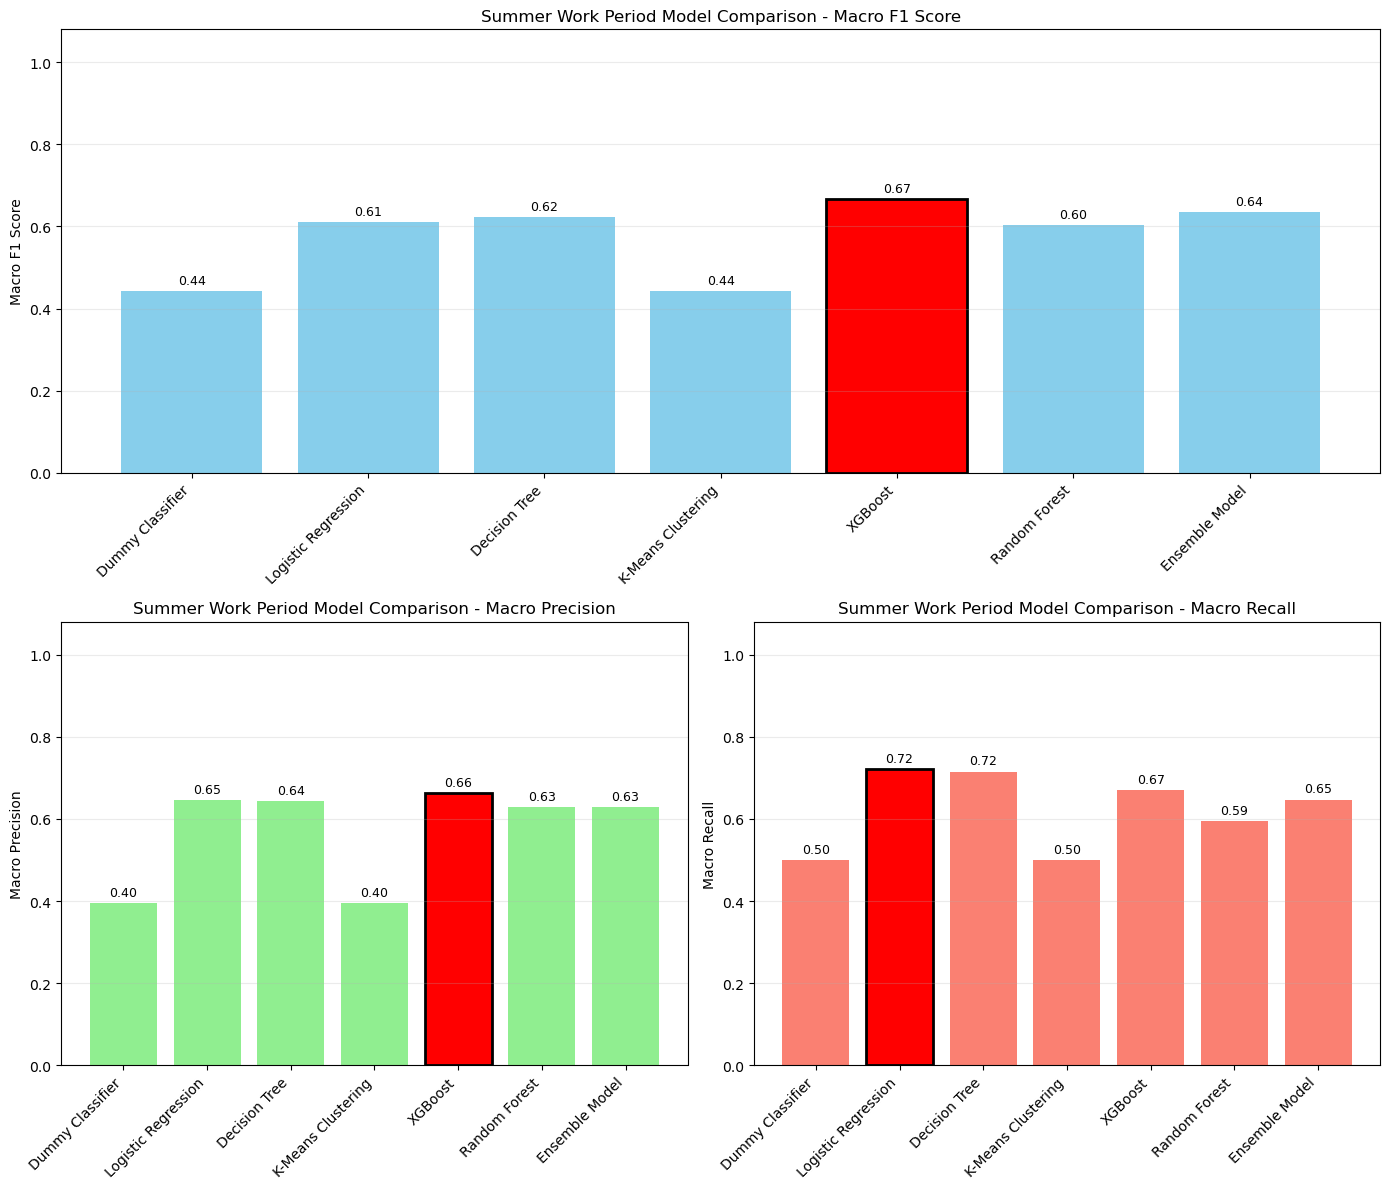

/var/folders/bg/1f1k786920g5016jzpkv6dxc0000gn/T/ipykernel_1869/3065822702.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="F1-Score", data=summer_results_df, palette="Set2")


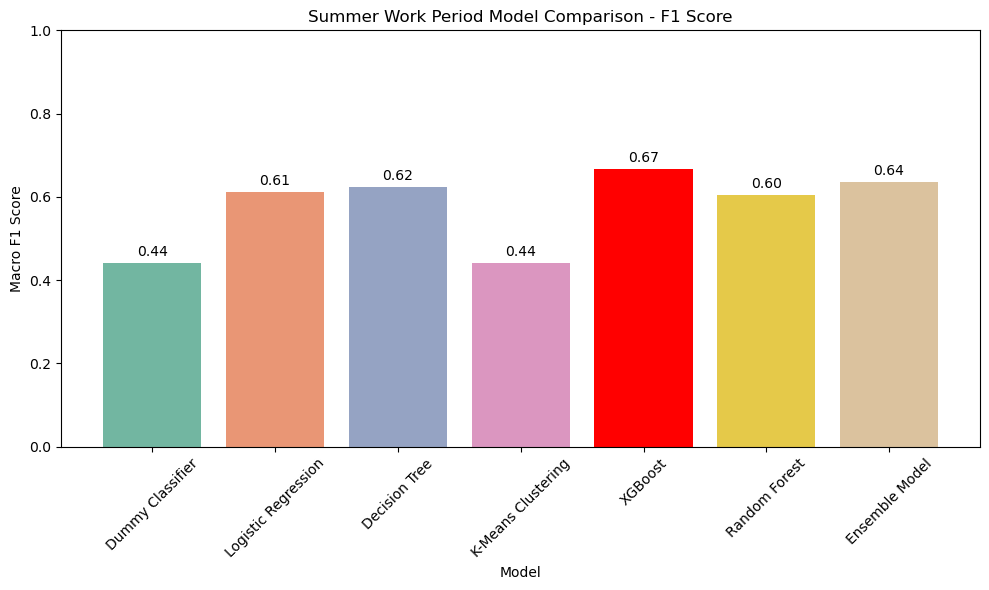

/var/folders/bg/1f1k786920g5016jzpkv6dxc0000gn/T/ipykernel_1869/3065822702.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Precision", data=summer_results_df, palette="Set2")


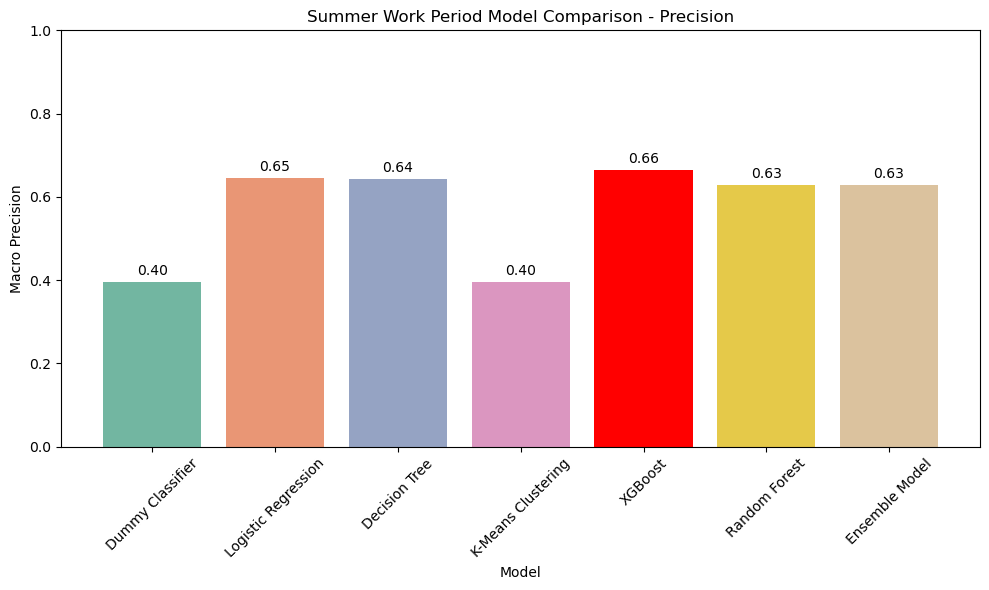

/var/folders/bg/1f1k786920g5016jzpkv6dxc0000gn/T/ipykernel_1869/3065822702.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Recall", data=summer_results_df, palette="Set2")


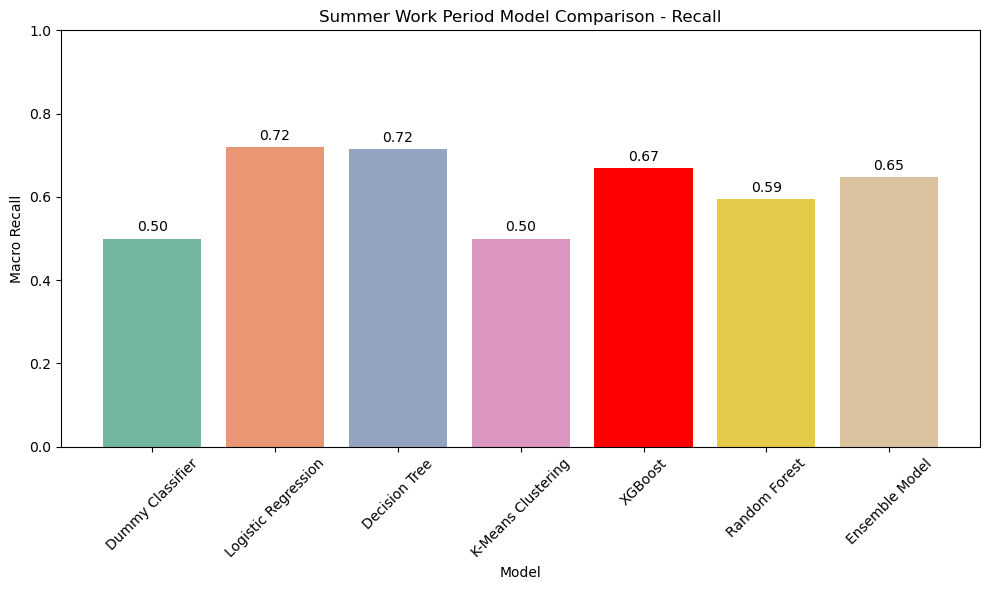

In [221]:
# Saving the summer results for all the models.
# Also highlighting the best performing model for each macro metric.

# First graph is having all three metrics in one graph and 
# then we will have separate graphs for each metric to have a better visualization of the performance of each model for each metric.

summer_results_df.to_csv(summerpath / "summer_model_comparison.csv", index=False)

fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(2, 2)

ax_f1 = fig.add_subplot(gs[0, :])
ax_precision = fig.add_subplot(gs[1, 0])
ax_recall = fig.add_subplot(gs[1, 1])

x = np.arange(len(summer_results_df["Model"]))
models = summer_results_df["Model"]

def plot_metric(ax, metric, title, ylabel, color):
    bars = ax.bar(x, summer_results_df[metric], color=color)

    best_index = summer_results_df[metric].idxmax()
    bars[best_index].set_color("red")
    bars[best_index].set_edgecolor("black")
    bars[best_index].set_linewidth(2)

    for index, value in enumerate(summer_results_df[metric]):
        ax.text(index,value + 0.01,f"{value:.2f}",ha="center",va="bottom",fontsize=9)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.08)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.25)

plot_metric(ax_f1,"F1-Score","Summer Work Period Model Comparison - Macro F1 Score","Macro F1 Score","skyblue")

plot_metric(ax_precision,"Precision", "Summer Work Period Model Comparison - Macro Precision","Macro Precision","lightgreen")
plot_metric( ax_recall, "Recall", "Summer Work Period Model Comparison - Macro Recall","Macro Recall", "salmon")

plt.tight_layout()
plt.savefig(summerpath / "summer_model_comparison_all_metrics.png",dpi=300,bbox_inches="tight")
plt.show()



# Using sns bar plot tp compare the performance of all the models for the summer work period and highlighting the best performing model in terms of macro f1 score.
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="F1-Score", data=summer_results_df, palette="Set2")
plt.title("Summer Work Period Model Comparison - F1 Score")
plt.ylabel("Macro F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
# Highlight the best performing model
best_model_index = summer_results_df["F1-Score"].idxmax()
plt.bar(best_model_index, summer_results_df.loc[best_model_index, "F1-Score"], color="red")
# Also adding the number values on top of the bars for f1 scores.
for index, row in summer_results_df.iterrows():
    plt.text(index, row["F1-Score"] + 0.01, f"{row['F1-Score']:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(summerpath / "summer_model_comparison_f1_score.png", dpi=300, bbox_inches="tight")
plt.show()


# Precision and recall comparison for the summer work period models.
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Precision", data=summer_results_df, palette="Set2")
plt.title("Summer Work Period Model Comparison - Precision")
plt.ylabel("Macro Precision")
plt.ylim(0, 1)
plt.xticks(rotation=45)
best_model_index = summer_results_df["F1-Score"].idxmax()
plt.bar(best_model_index, summer_results_df.loc[best_model_index, "Precision"], color="red")
# Also adding the number values on top of the bars for precision scores.
for index, row in summer_results_df.iterrows():
    plt.text(index, row["Precision"] + 0.01, f"{row['Precision']:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(summerpath / "summer_model_comparison_precision.png", dpi=300, bbox_inches="tight")
plt.show()


# Recall comparison for the summer work period models.
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Recall", data=summer_results_df, palette="Set2")
plt.title("Summer Work Period Model Comparison - Recall")
plt.ylabel("Macro Recall")
plt.ylim(0, 1)
plt.xticks(rotation=45)
best_model_index = summer_results_df["F1-Score"].idxmax()
plt.bar(best_model_index, summer_results_df.loc[best_model_index, "Recall"], color="red")
# Also adding the number values on top of the bars for recall scores.
for index, row in summer_results_df.iterrows():
    plt.text(index, row["Recall"] + 0.01, f"{row['Recall']:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(summerpath / "summer_model_comparison_recall.png", dpi=300, bbox_inches="tight")
plt.show()